## DMRG WITH TENPY

In [2]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import pickle
import os
from tqdm import tqdm

import tenpy
from tenpy import CouplingMPOModel, SpinHalfSite
import tenpy.linalg.np_conserved as npc
from tenpy.algorithms import dmrg
from tenpy.networks.mps import MPS
from tenpy.models.tf_ising import TFIChain
from tenpy.simulations.measurement import m_energy_MPO
from scipy.optimize import curve_fit

np.set_printoptions(precision=5, suppress=True, linewidth=100)
plt.rcParams['figure.dpi'] = 150

L = 250

filename_master = os.path.join(os.getcwd(), f"L{L}-full")

## My MPO

In [12]:
class myModel(CouplingMPOModel):
    def init_sites(self, model_params):
        site = SpinHalfSite(conserve=None)
        return site
    
    def init_terms(self, model_params):
        Jx = model_params.get('Jx', 1.0)
        hz = model_params.get('hz', 0.0)
        kl = model_params.get('kl', 0.0)
        kr = model_params.get('kr', 0.0)

        # Onsite magnetic field
        for u in range(len(self.lat.unit_cell)):
            self.add_onsite(hz, u, 'Sigmaz')

        # Nearest-neighbor XX coupling
        for u1, u2, dx in self.lat.pairs['nearest_neighbors']:
            self.add_coupling(Jx, u1, 'Sigmax', u2, 'Sigmax', dx)

        # 3-site interactions (already Hermitian)
        dx = [(0,), (1,), (2,)]
        u = 0  # single-site unit cell

        self.add_multi_coupling(
            kl,
            [('Sigmax', dx[0], u), ('Sigmay', dx[1], u), ('Sigmaz', dx[2], u)]
        )
        self.add_multi_coupling(
            -kl,
            [('Sigmay', dx[0], u), ('Id', dx[1], u), ('Sigmax', dx[2], u)]
        )
        self.add_multi_coupling(
            -kr,
            [('Sigmaz', dx[0], u), ('Sigmay', dx[1], u), ('Sigmax', dx[2], u)]
        )
        self.add_multi_coupling(
            kr,
            [('Sigmax', dx[0], u), ('Id', dx[1], u), ('Sigmay', dx[2], u)]
        )

        # add boundary conditions
        self.add_onsite_term(10, 0, "Sigmax")
        self.add_onsite_term(-10, L-1, "Sigmax")

def dmrg_sim(Jx, hz, kl, kr, filename):
    dmrg_params = {
    'mixer': True,  # setting this to True helps to escape local minima
    'max_E_err': 1.e-4,
    'trunc_params': {
        'chi_max': 100,
        'svd_min': 1.e-10,
    },
    'combine': True
    }

    model_params = {
    'Jx': Jx , 'hz': hz, 'kl': kl, 'kr': kr,
    'L': L,
    'bc_MPS': 'finite',
    }

    M = myModel(model_params)
    psi = MPS.from_lat_product_state(M.lat, [['up']])

    eng = dmrg.TwoSiteDMRGEngine(psi, M, dmrg_params)
    E, psi = eng.run() # the main work; modifies psi in place

    # save to file
    data = {'psi': psi, 'dmrg_params': dmrg_params, 'model_params': model_params}

    os.makedirs(filename, exist_ok=True)
        
    loc = os.path.join(filename, f'{hz:.3f}_{kl:.3f}.pkl')
    with open(loc, 'wb') as f:
        pickle.dump(data, f)
    
    return M

def dmrg_lines(start, stop, step, fixed, filename, setval="k", Jx=1):
    values = np.arange(start, stop+step, step)

    for sweep in values:
        if setval == "k":
            hz = sweep
            k = fixed
        elif setval == "h":
            hz = fixed
            k = sweep
        print(Jx, hz, k)
        M = dmrg_sim(Jx, hz, k, k, filename)
        print(M.all_coupling_terms().to_TermList() + M.all_onsite_terms().to_TermList())

# h_values = [0.25, 0.5, 0.75]

# for h in h_values:
#     filename = os.path.join(filename_master, f"h_{h}")
#     dmrg_lines(1.05, 2, 0.05, h, filename, setval="h")

## Energy

100%|██████████| 21/21 [00:07<00:00,  2.93it/s]
/tmp/ipykernel_539851/1595124565.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


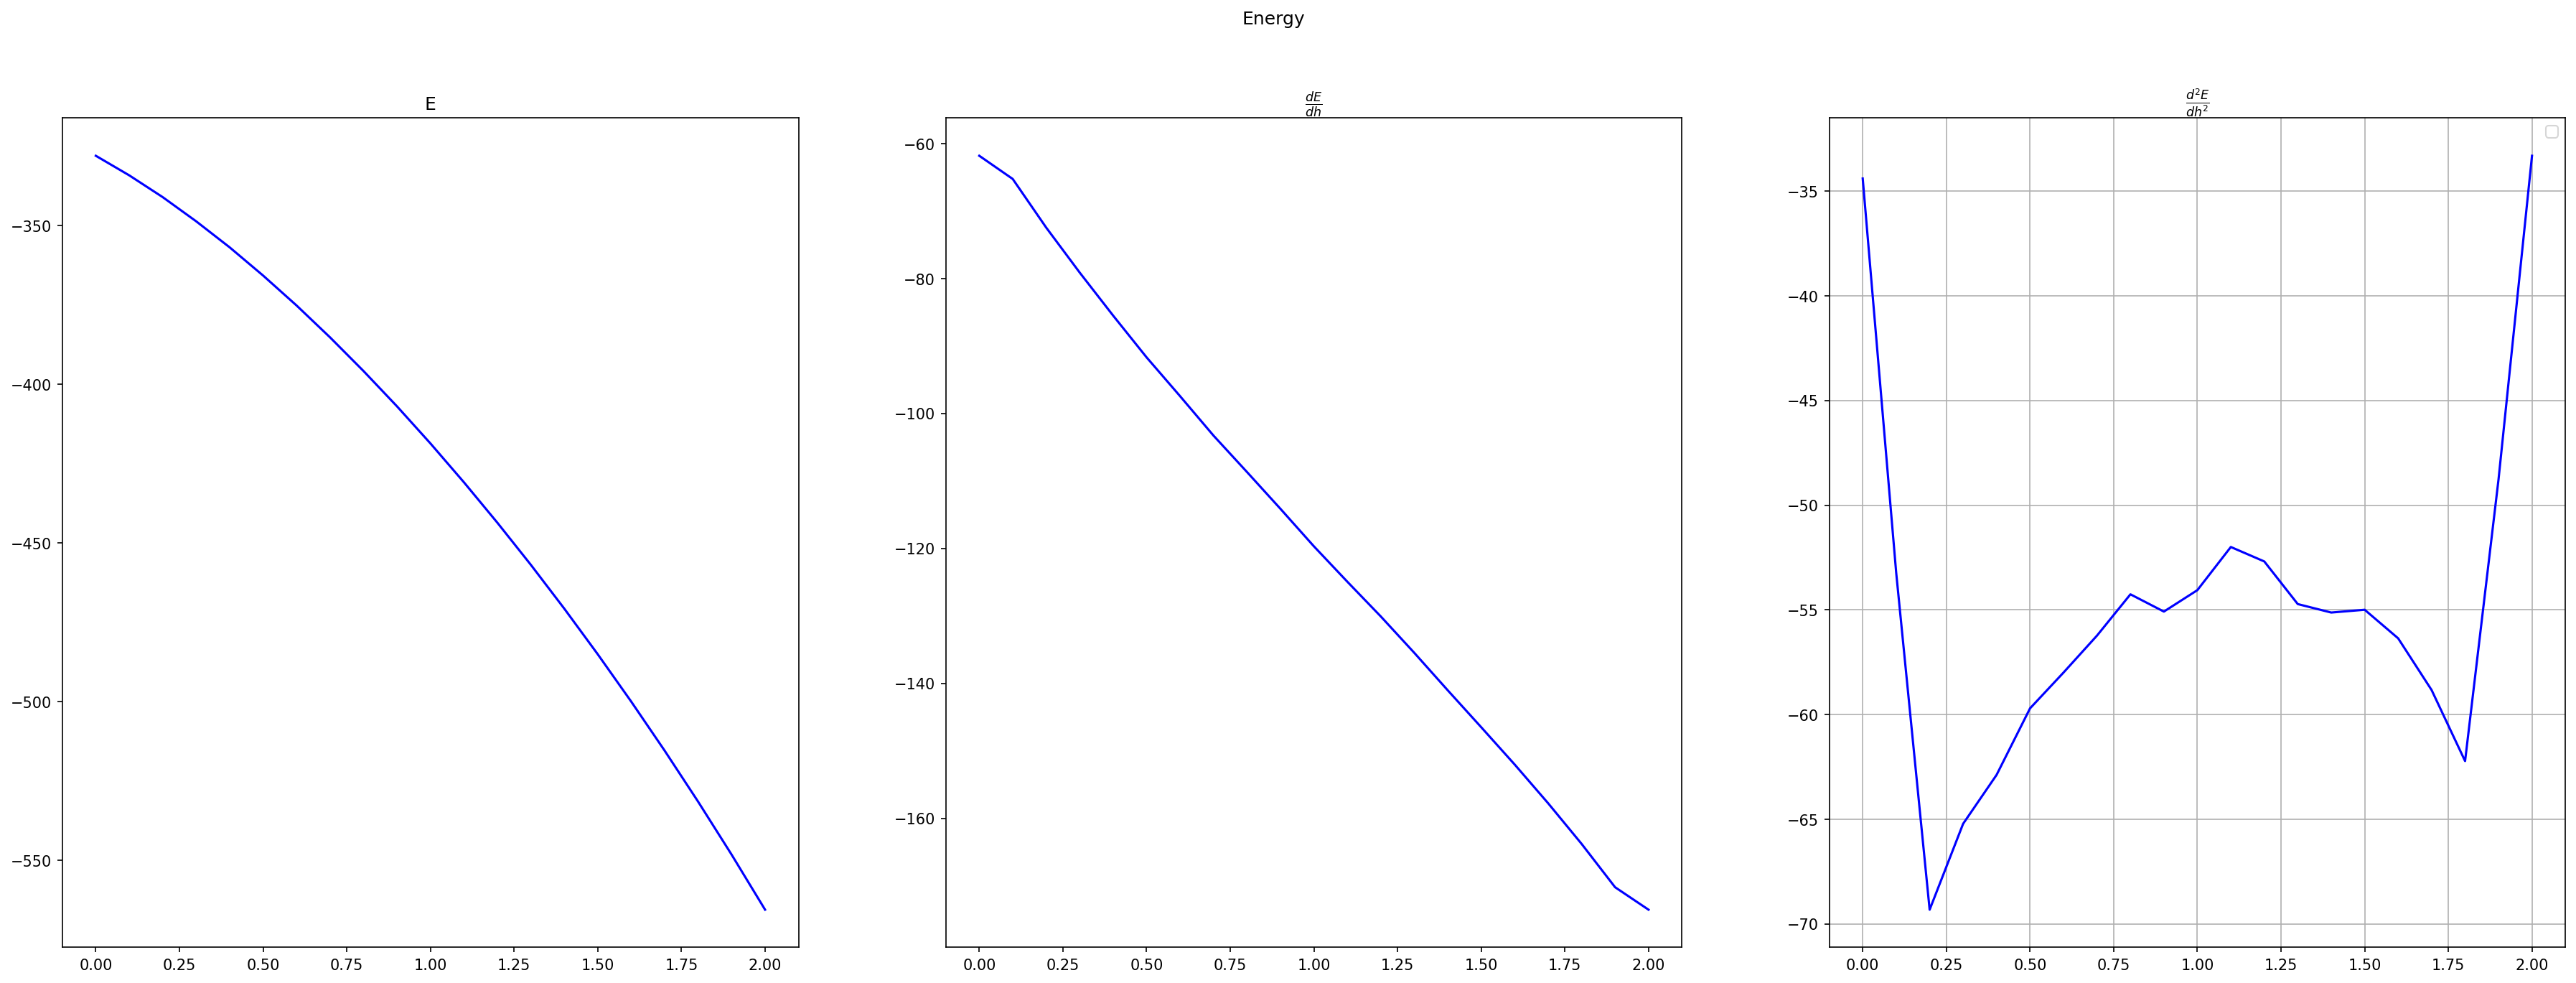

In [ ]:
h = [0.5]
slices = [1]
color = ["blue", "red", "green"]

fig, ax = plt.subplots(1, 3, figsize=(30, 10))

# look for energy kink
def find_energy(h):
    filename = os.path.join(os.getcwd(), f"L{L}-full", f"k_{h}")
    params = []
    E = []

    for i in tqdm(sorted(os.listdir(filename))):
        h, k = os.path.splitext(i)[0].split("_")[2:4]

        loc = os.path.join(filename, i)
        with open(loc, 'rb') as f:
            data = pickle.load(f)
            energy = data['energy']
            
        E.append(energy)
        params.append(float(h))
    return params, E

fig.suptitle("Energy")
for hx, slice, cor in zip(h, slices, color):
    params, E = find_energy(hx)
    dE_dparam = np.gradient(E, params)
    d2E_dparam2 = np.gradient(dE_dparam, params)
    ax[0].plot(params, E, c=cor)
    ax[1].plot(params, dE_dparam, c=cor)
    ax[2].plot(params, d2E_dparam2, c=cor)
    ax[0].set_title("E")
    ax[1].set_title(r"$\frac{dE}{dh}$")
    ax[2].set_title(r"$\frac{d^2E}{dh^2}$")

plt.legend()
plt.grid()
plt.show()

## Magnetization Profile

/home/ioannisangelotassioulas/Documents/master_thesis/books/L250-full/k_0.5


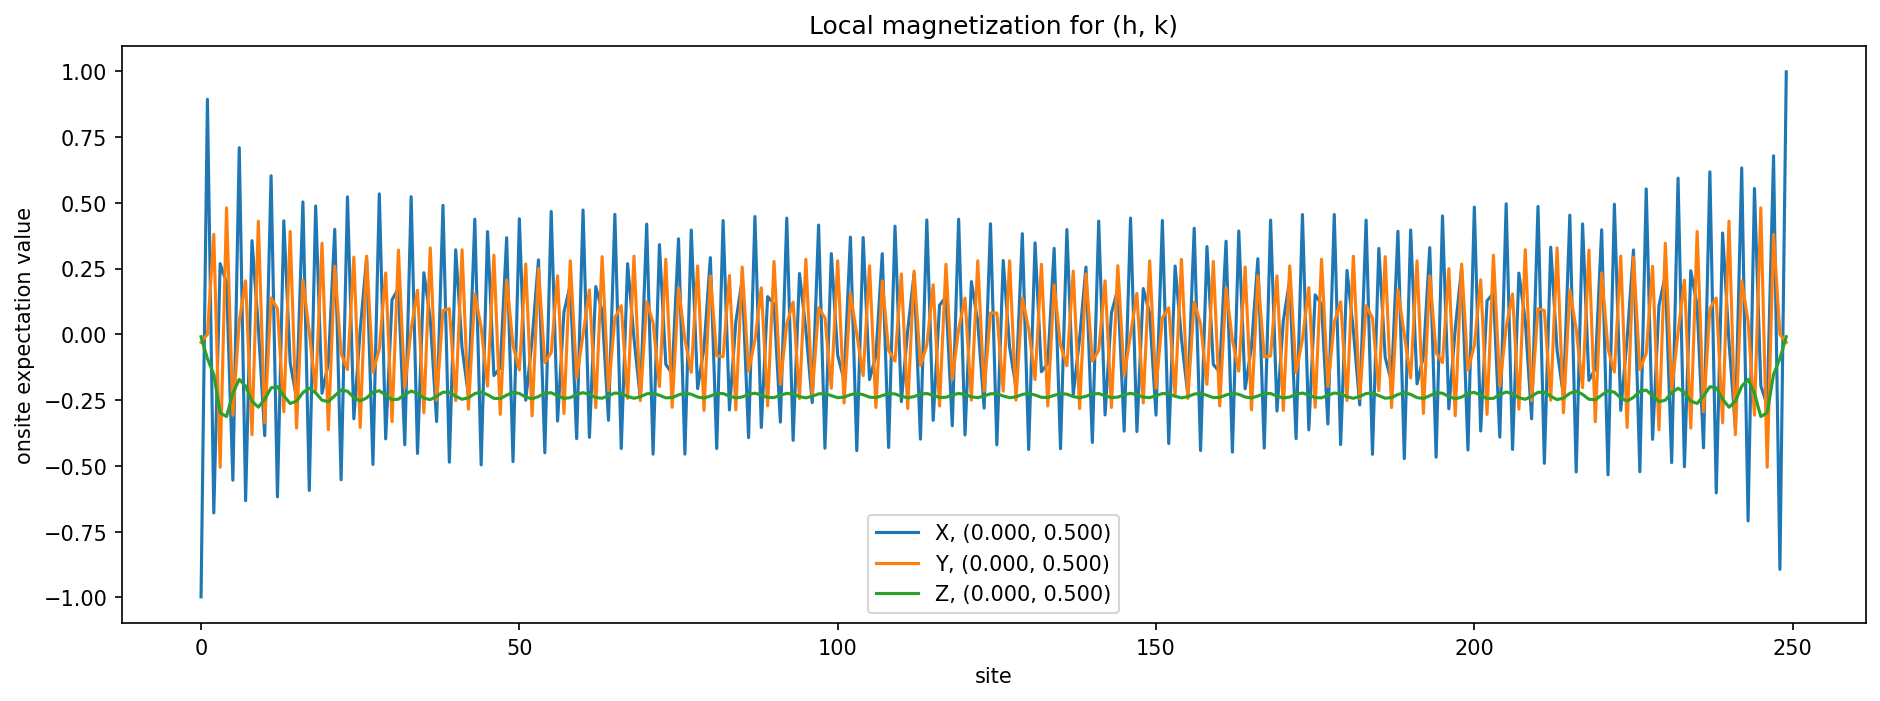

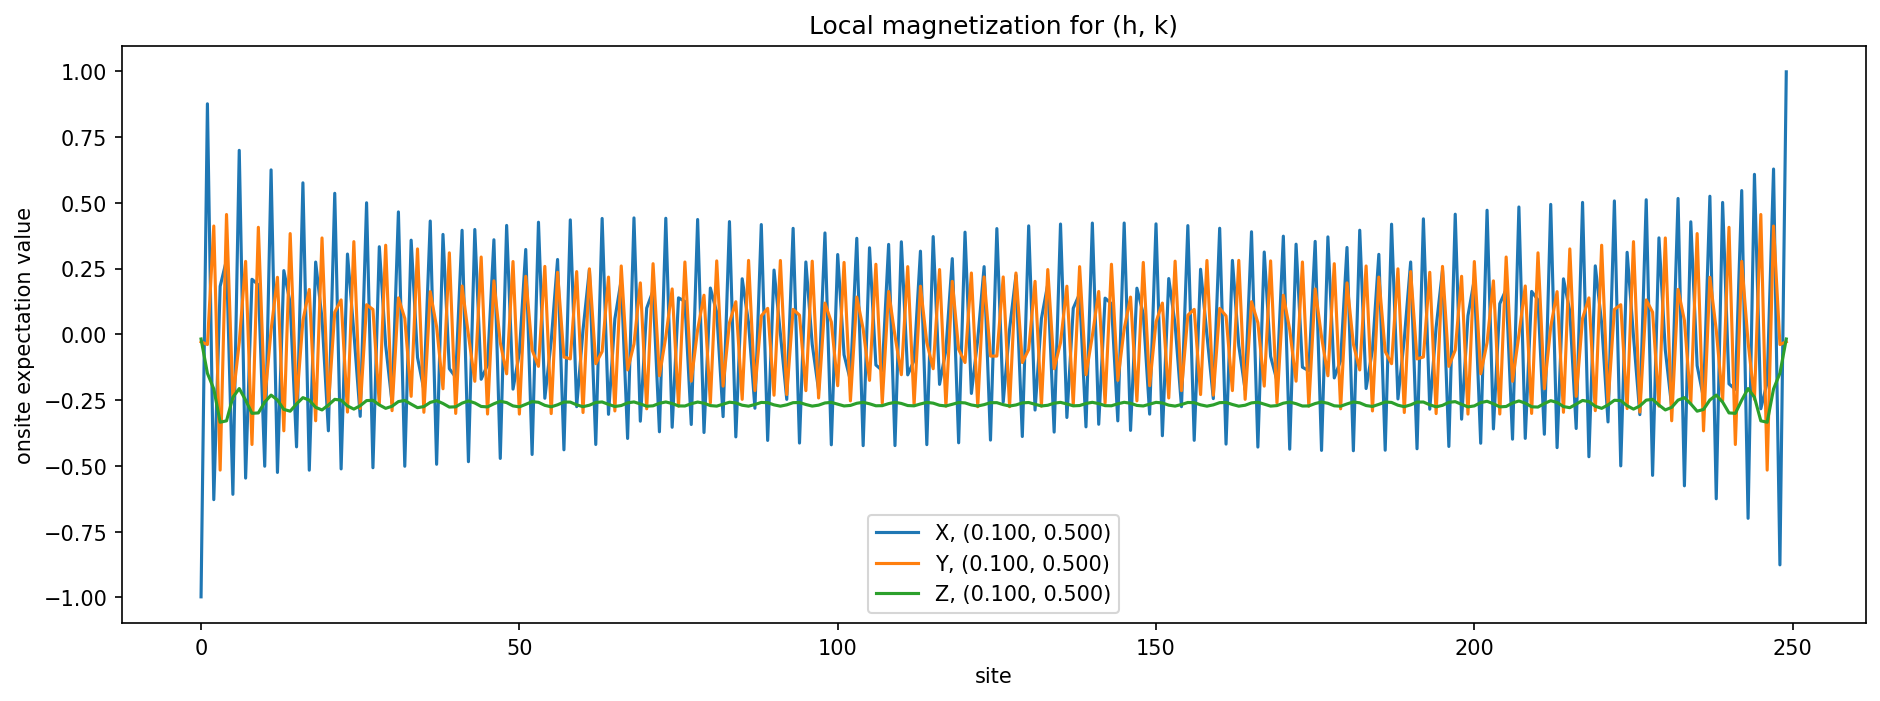

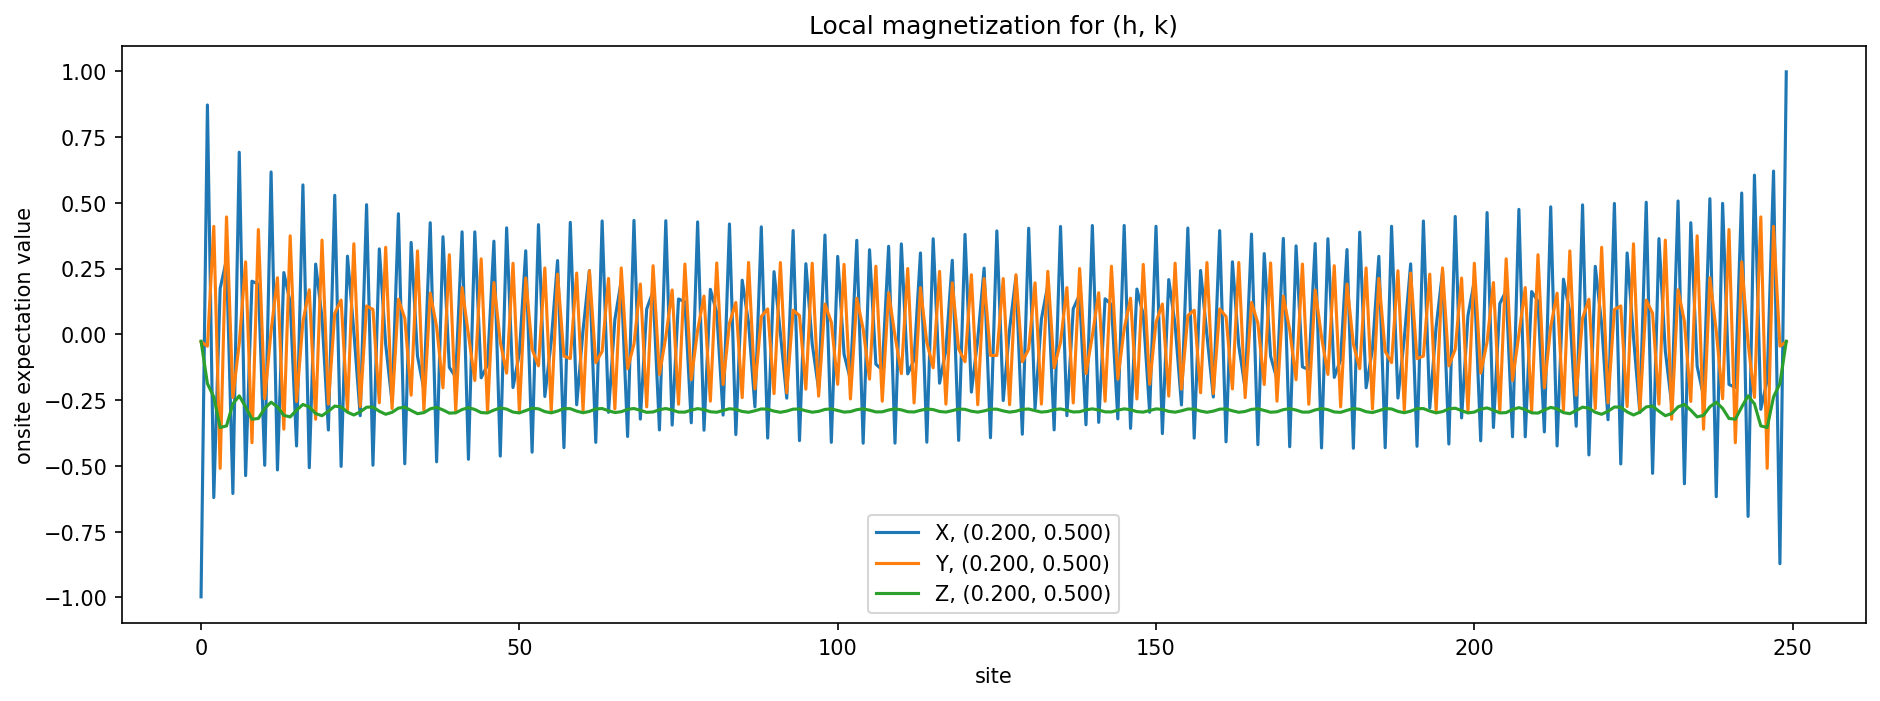

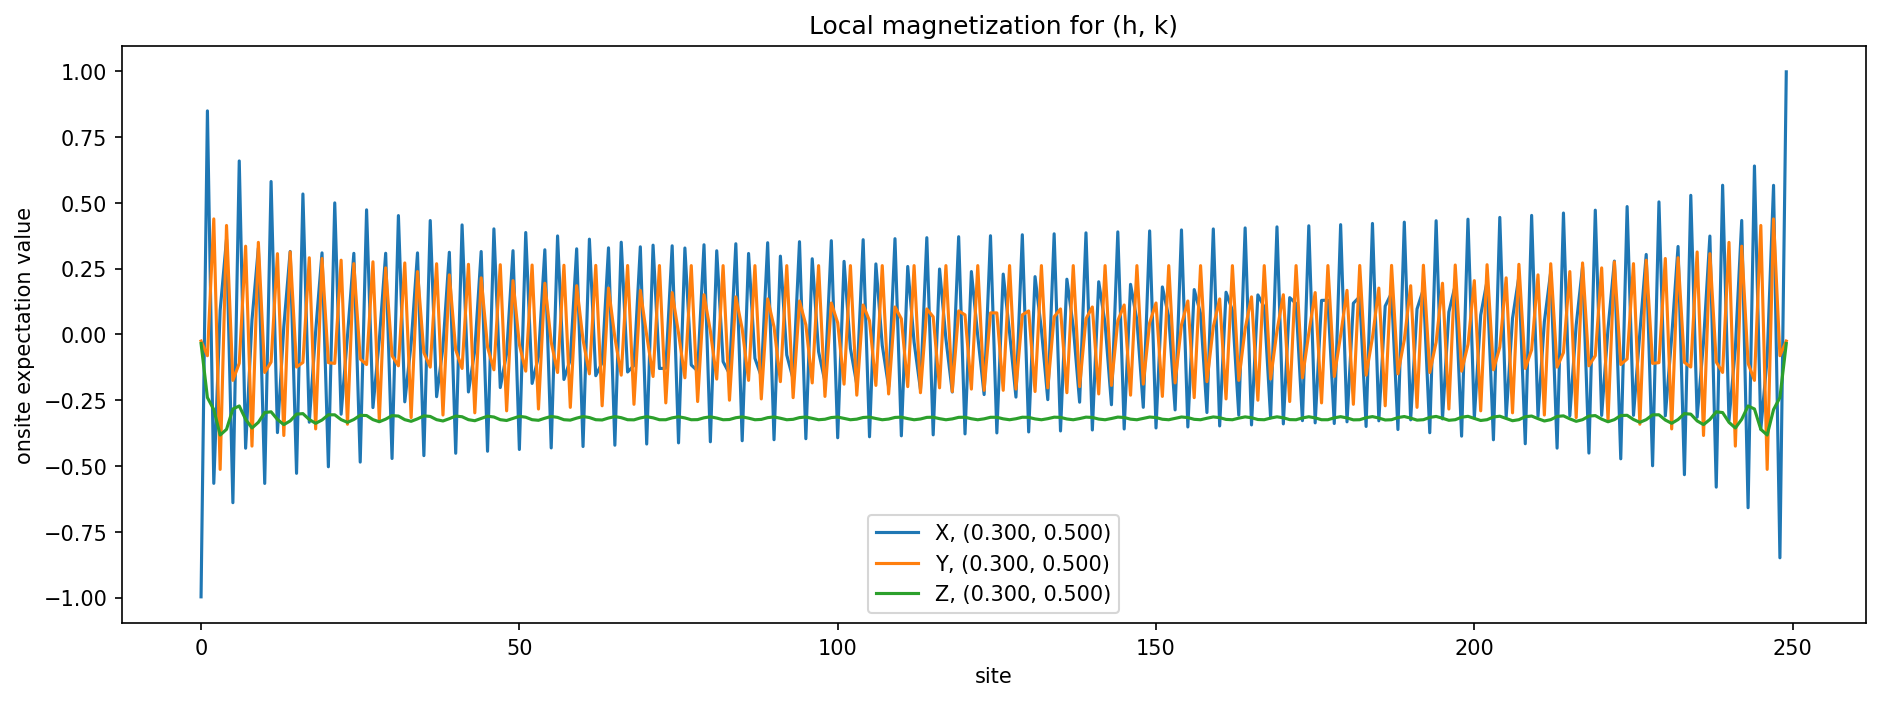

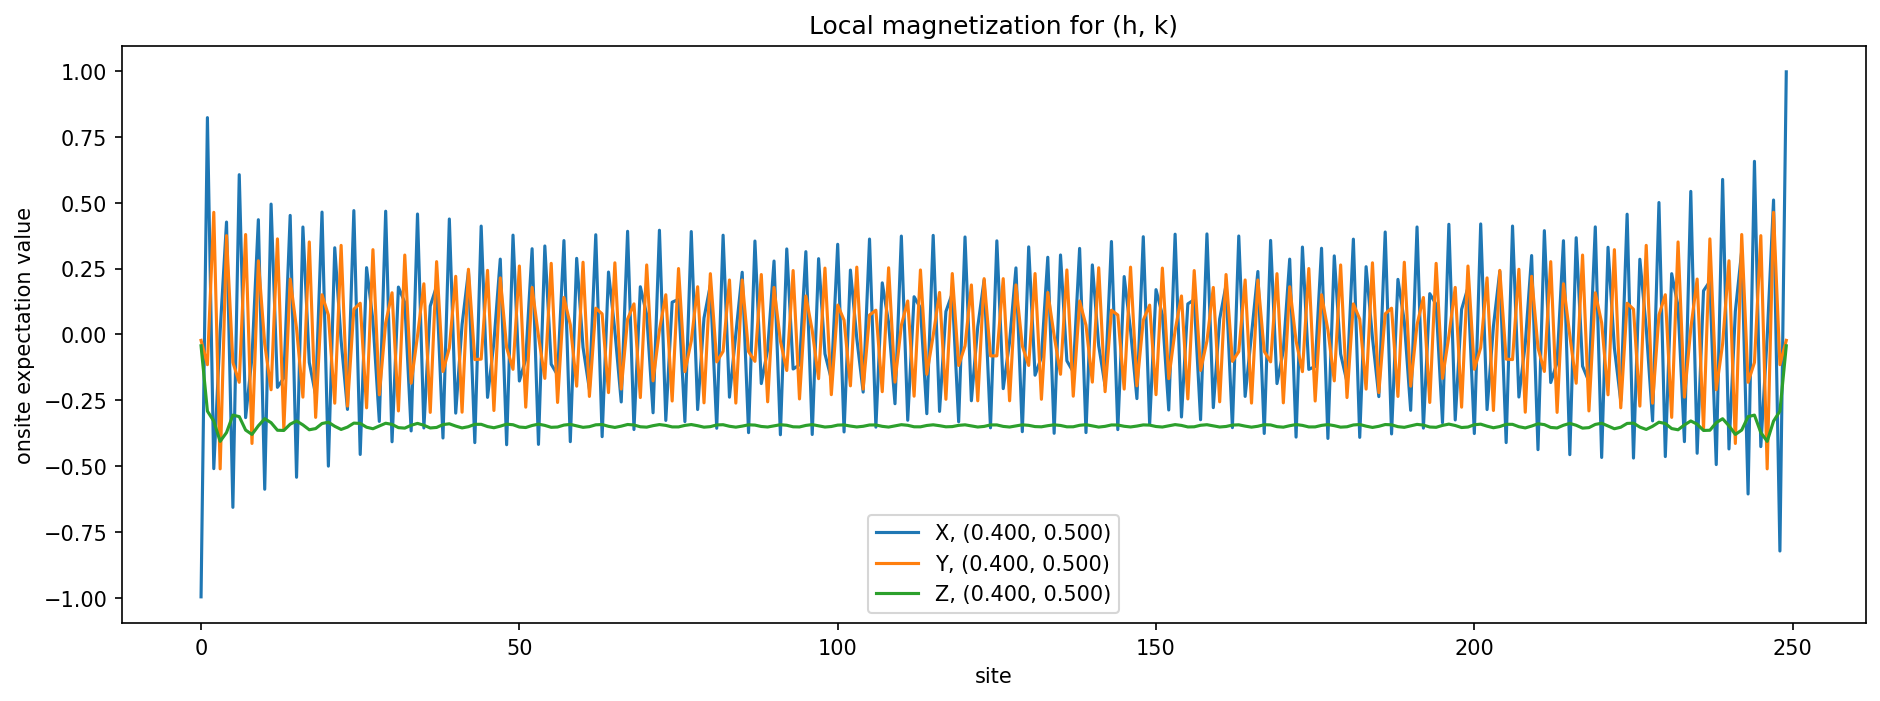

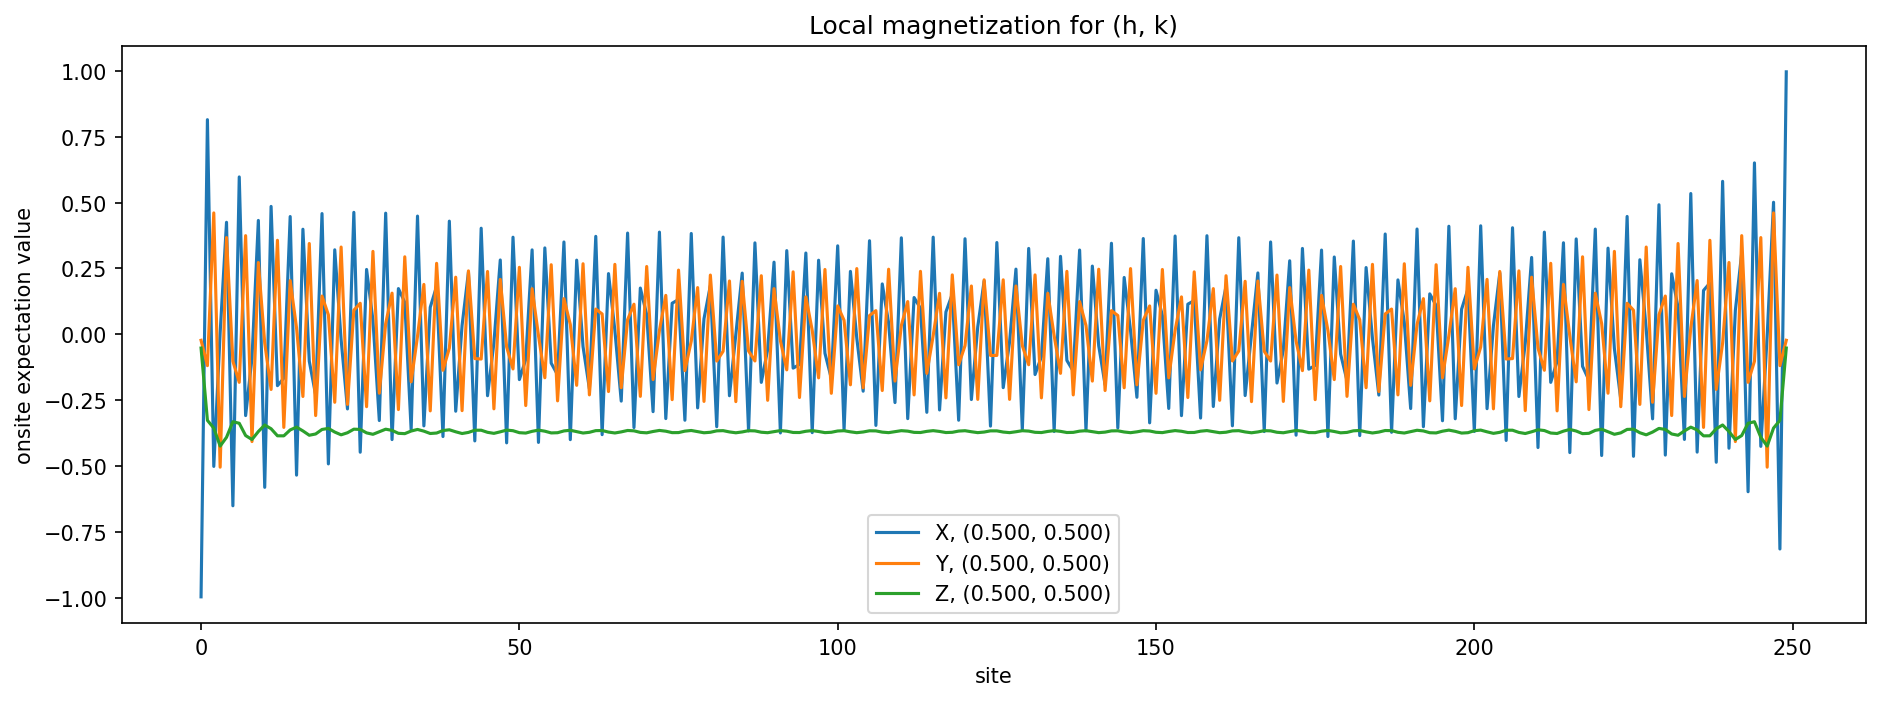

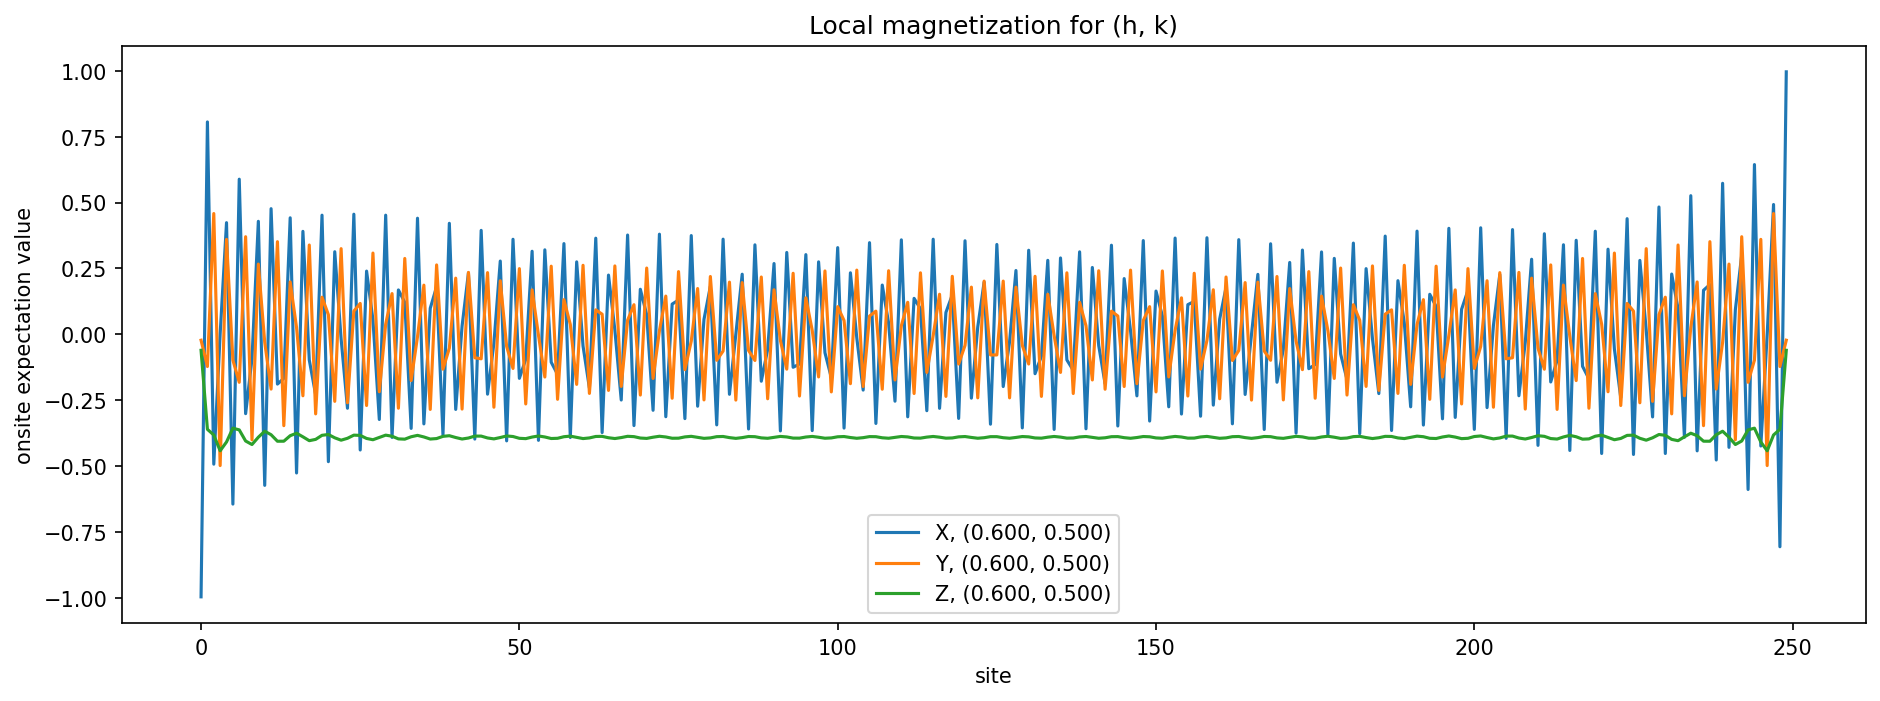

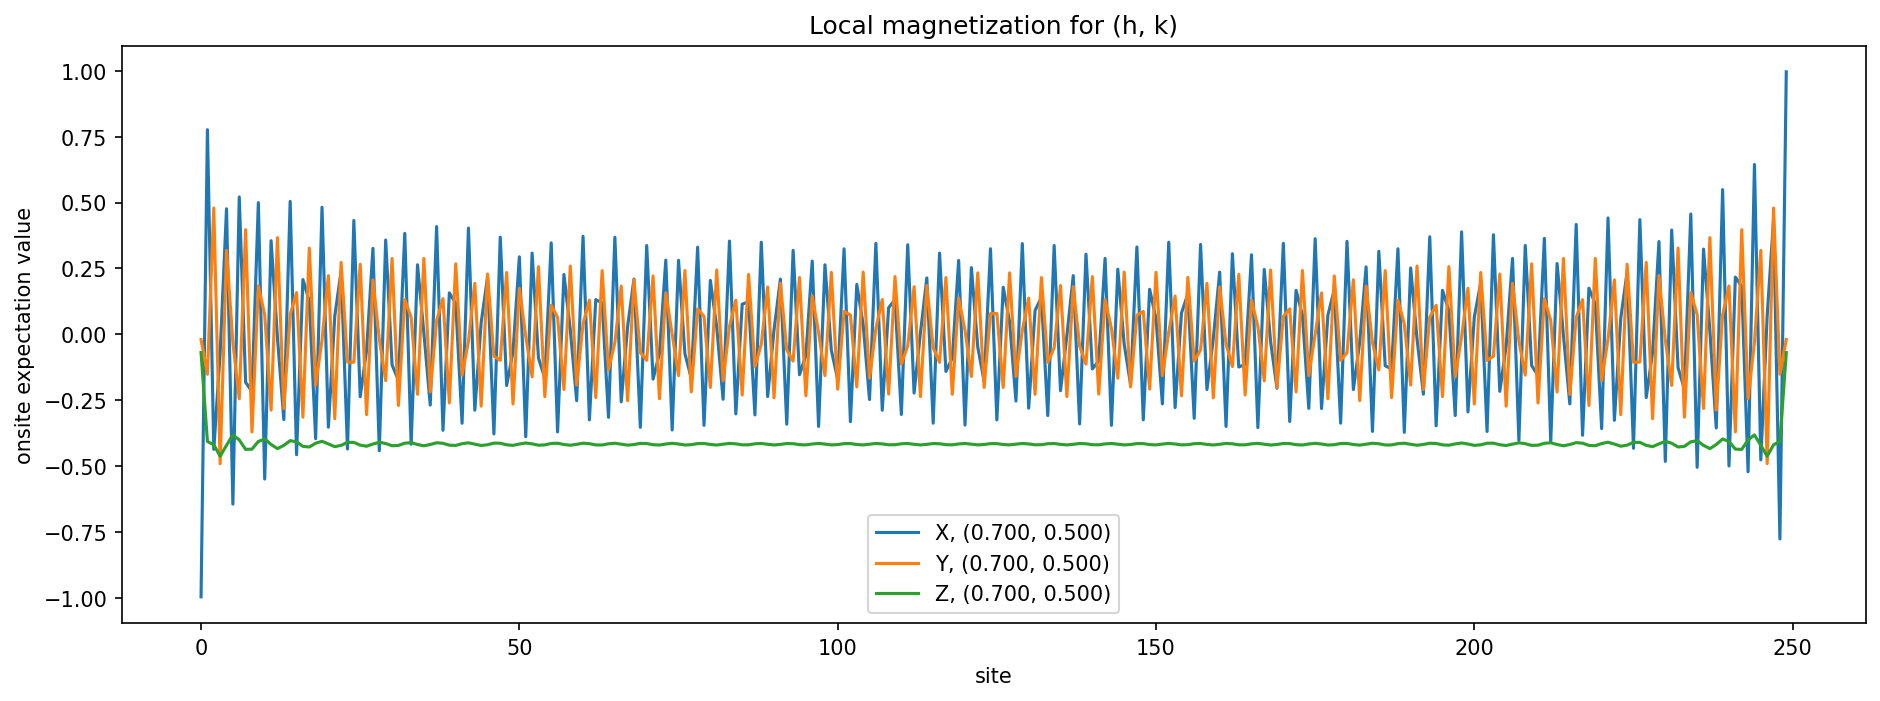

KeyboardInterrupt: 

<Figure size 2250x750 with 0 Axes>

In [8]:
# onsite expectation values
k=0.5
filename = os.path.join(os.getcwd(), f"L{L}-full", f"k_{k}")
print(filename)

for i in sorted(os.listdir(filename)):

    plt.figure(figsize=(15, 5))
    loc = os.path.join(filename, i)
    with open(loc, 'rb') as f:
        data = pickle.load(f)
        psi = data['psi']
    i = os.path.splitext(i)[0]
    h, k = i.split("_")[2:4]
    # h, k = i.split("_")
    x = np.arange(psi.L)
    X = psi.expectation_value("Sigmax")
    Z = psi.expectation_value("Sigmaz")
    Y = psi.expectation_value("Sigmay")
    
    plt.plot(x, X, label=f"X, ({h}, {k})")
    plt.plot(x, Y, label=f"Y, ({h}, {k})")
    plt.plot(x, Z, label=f"Z, ({h}, {k})")
    plt.title("Local magnetization for (h, k)")
    plt.xlabel("site")
    plt.ylabel("onsite expectation value")
    plt.legend()
    plt.show()

## Duality Check

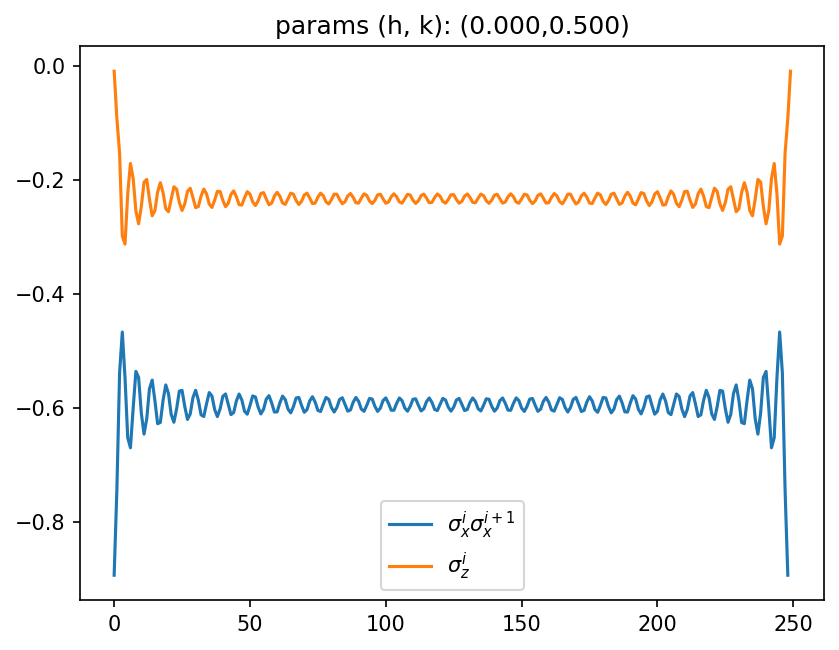

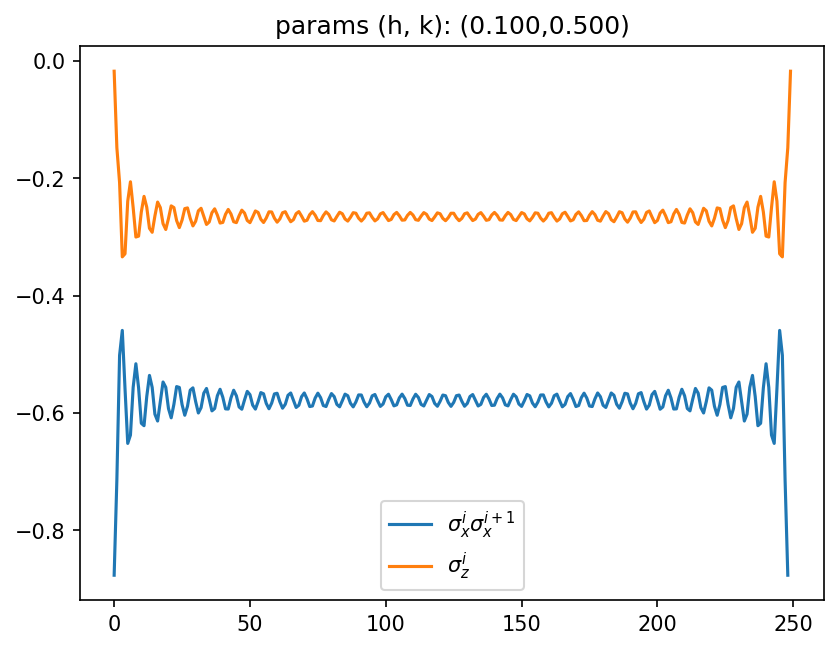

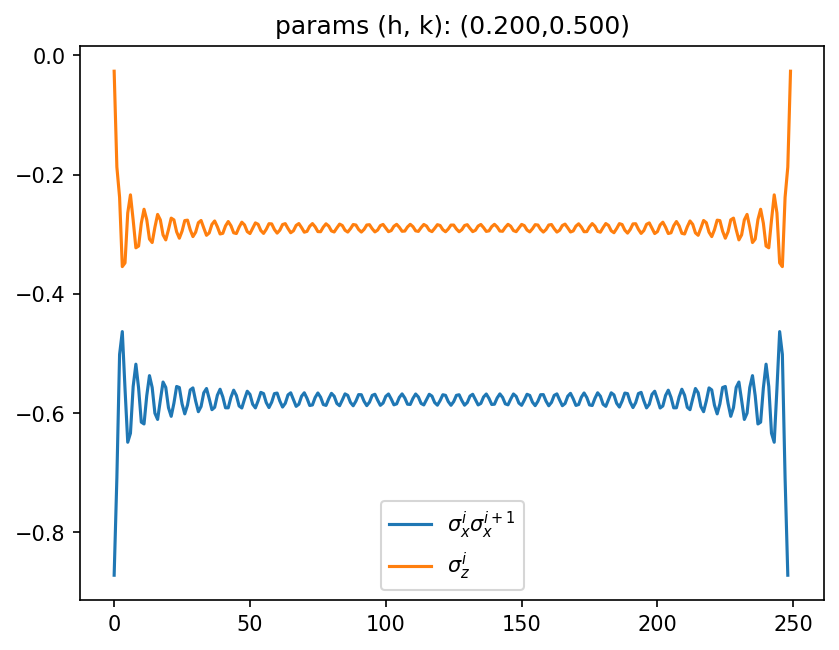

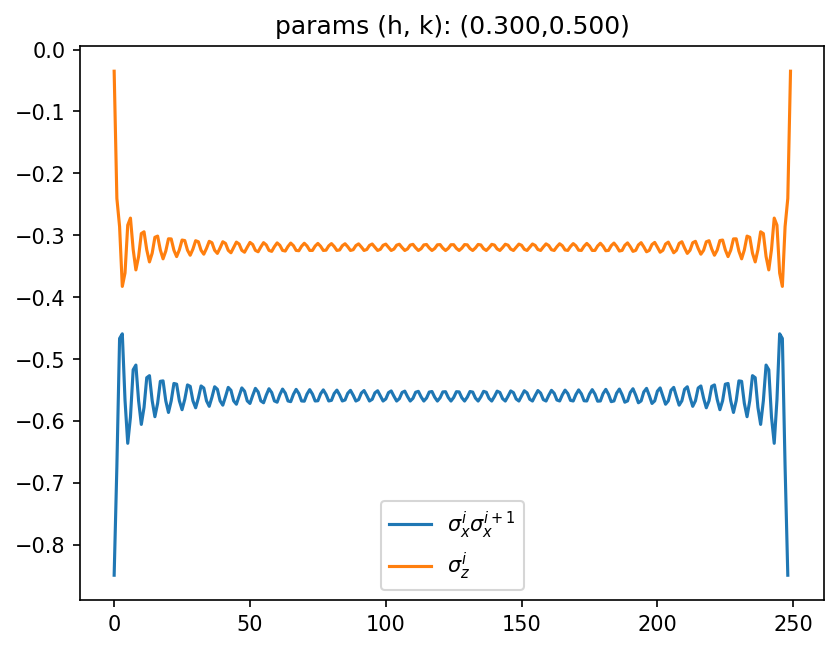

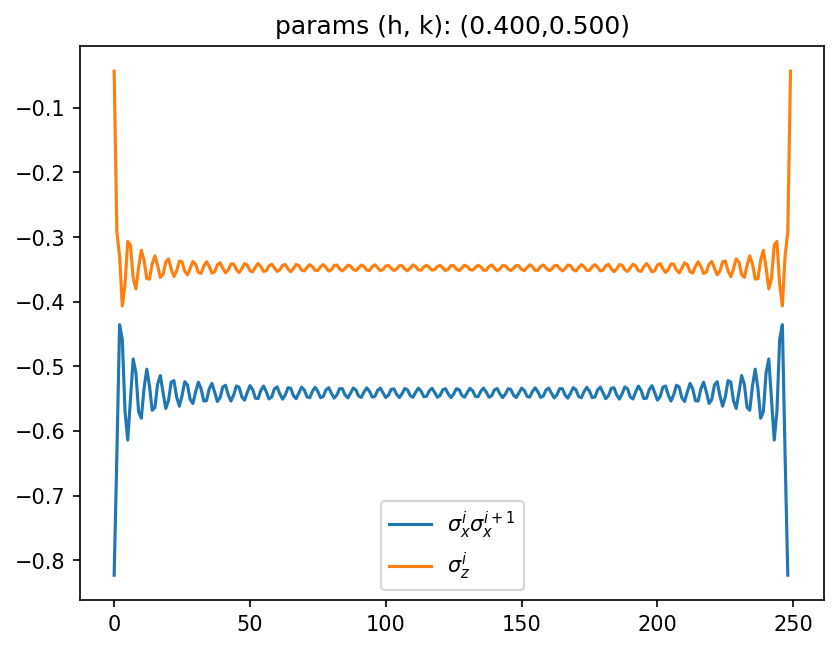

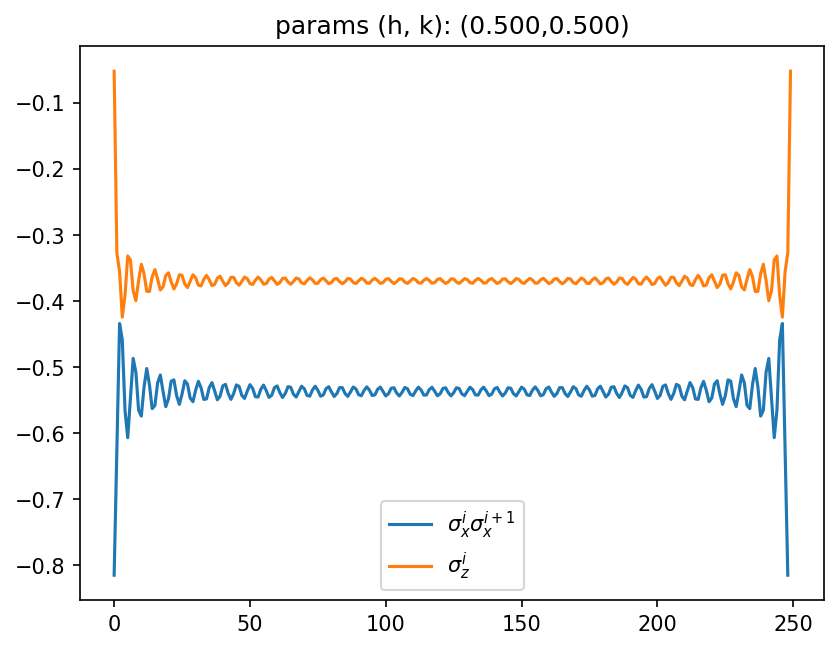

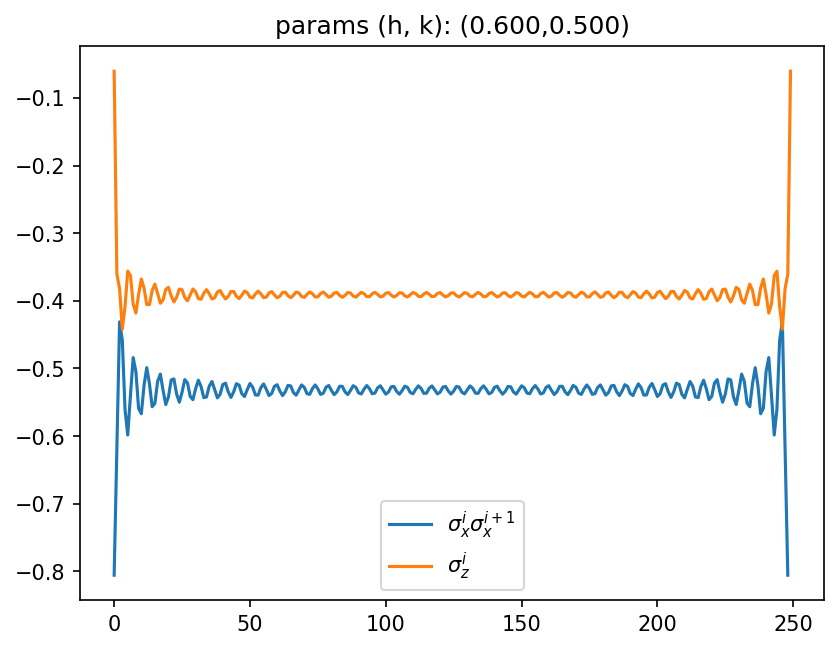

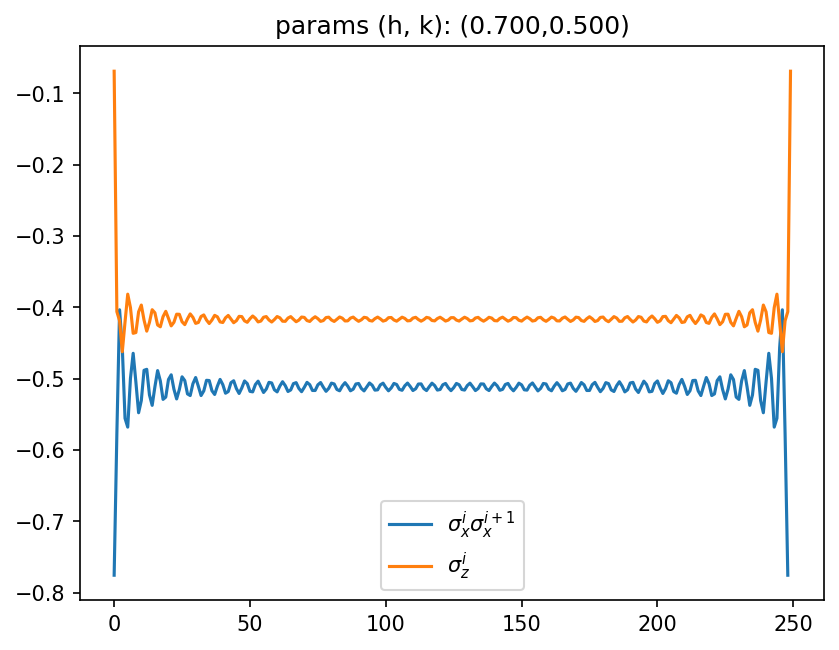

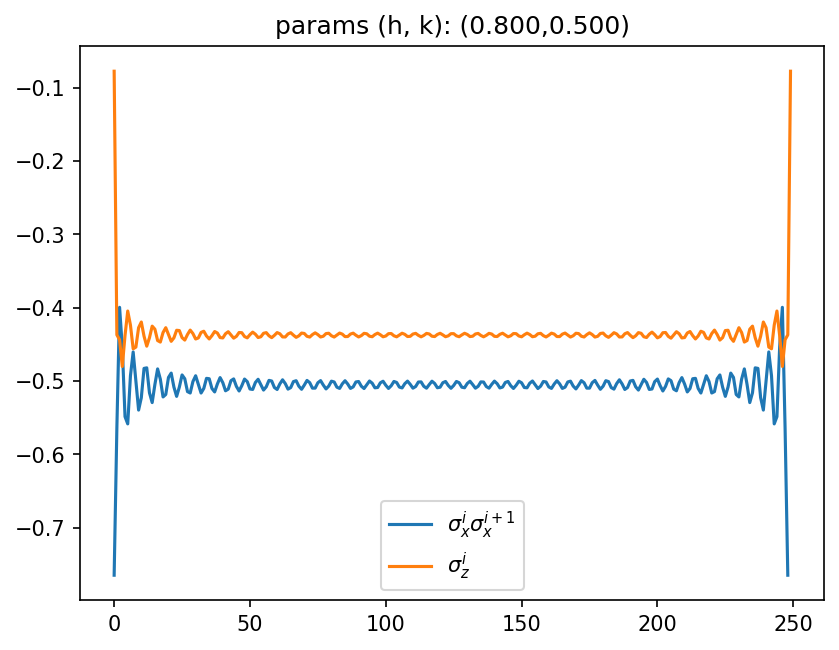

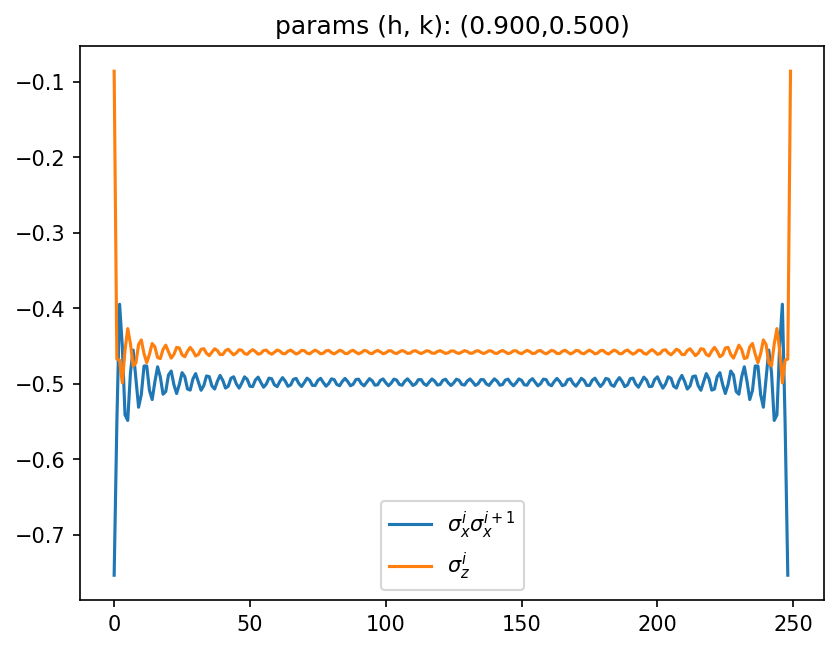

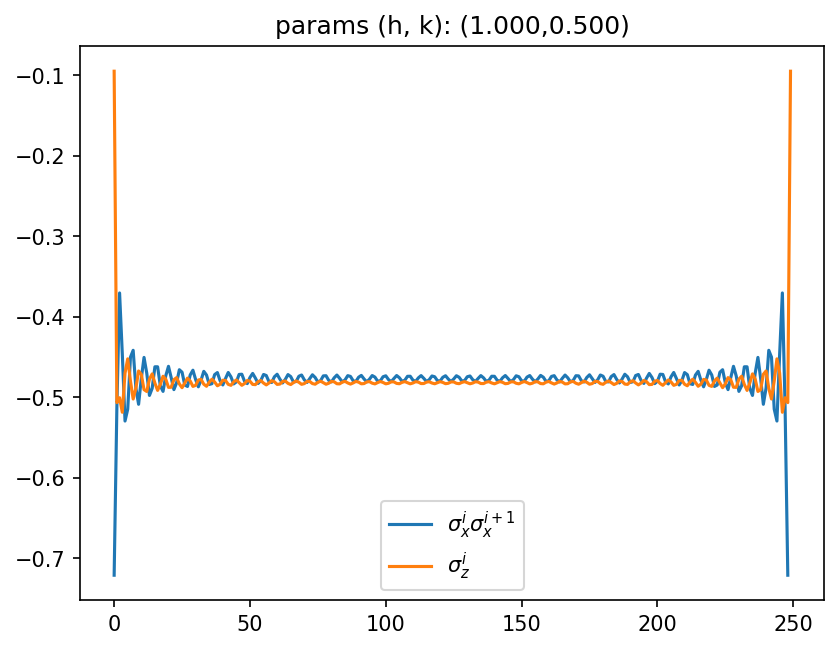

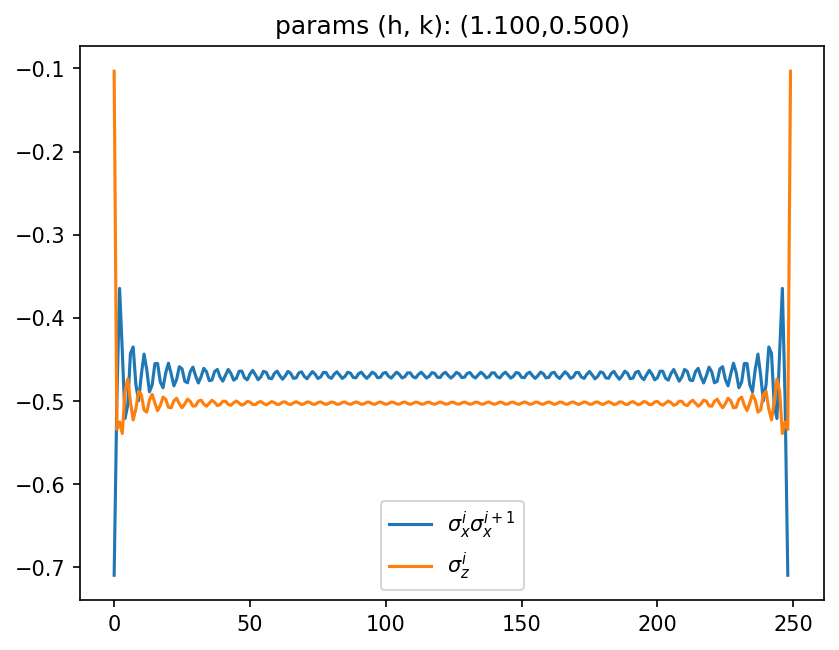

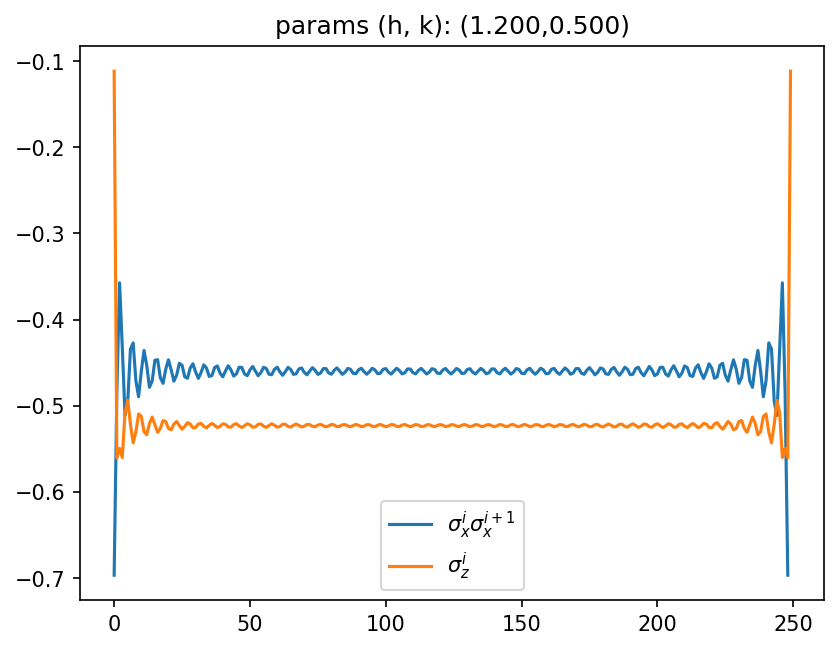

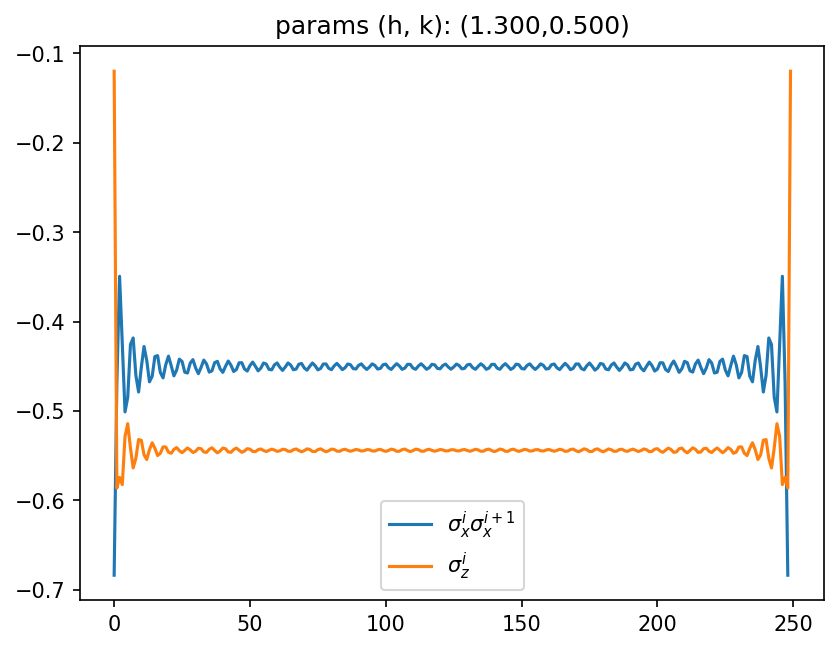

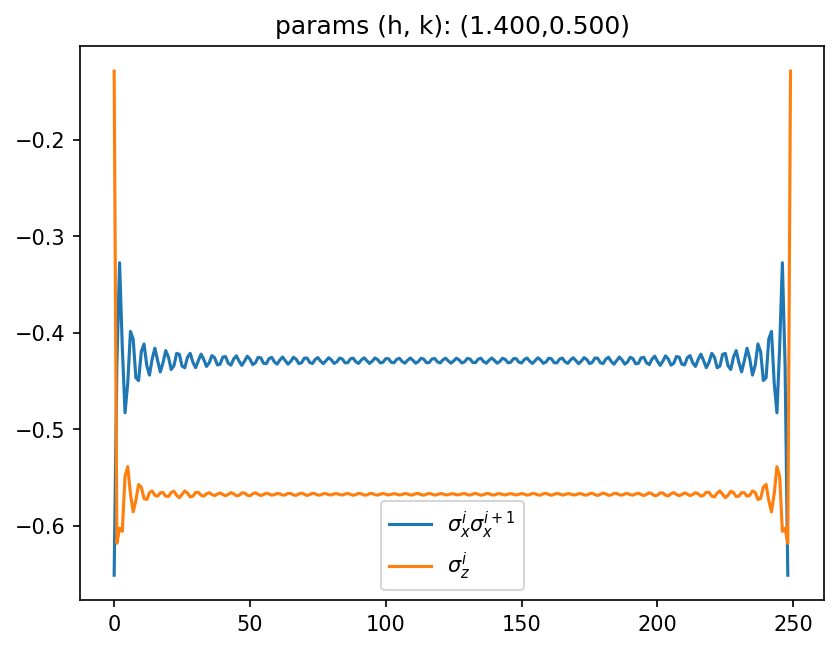

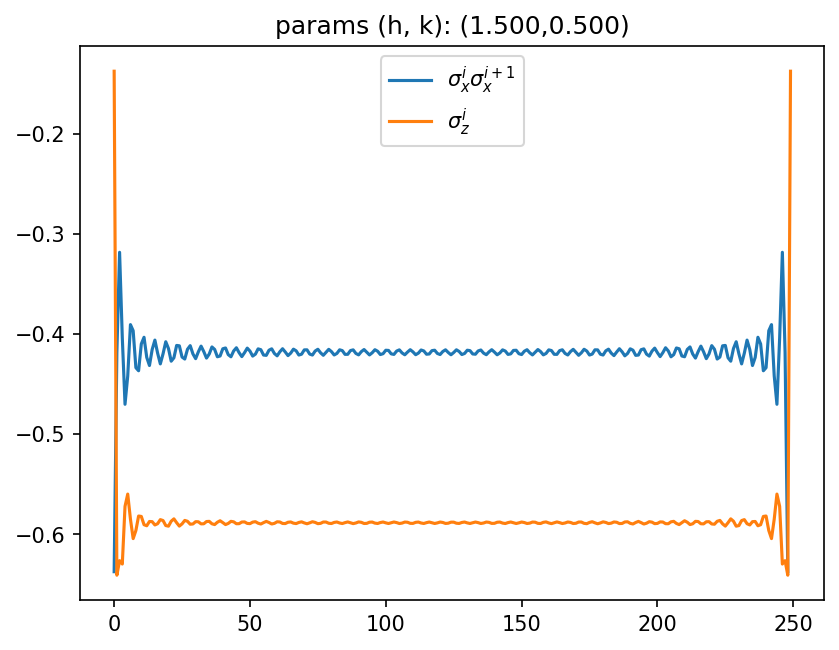

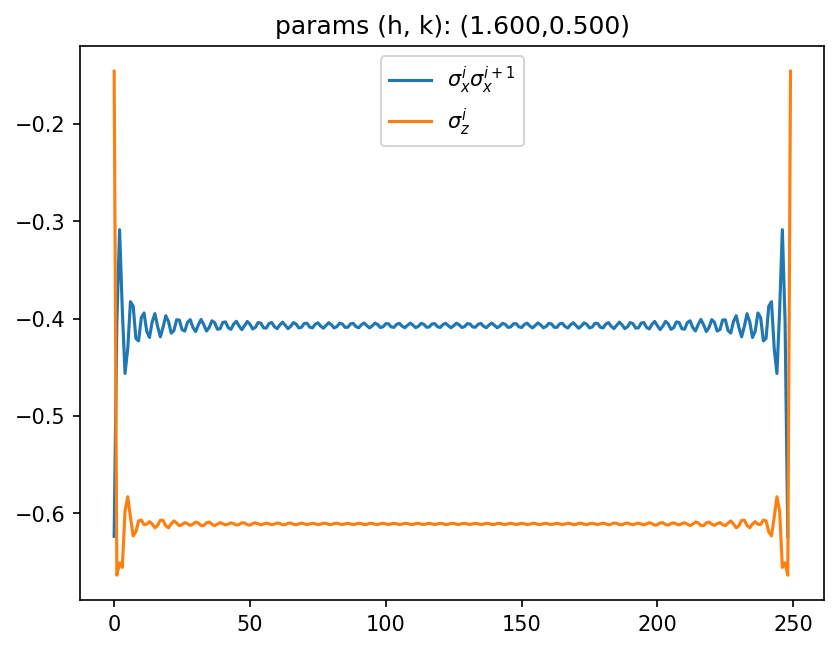

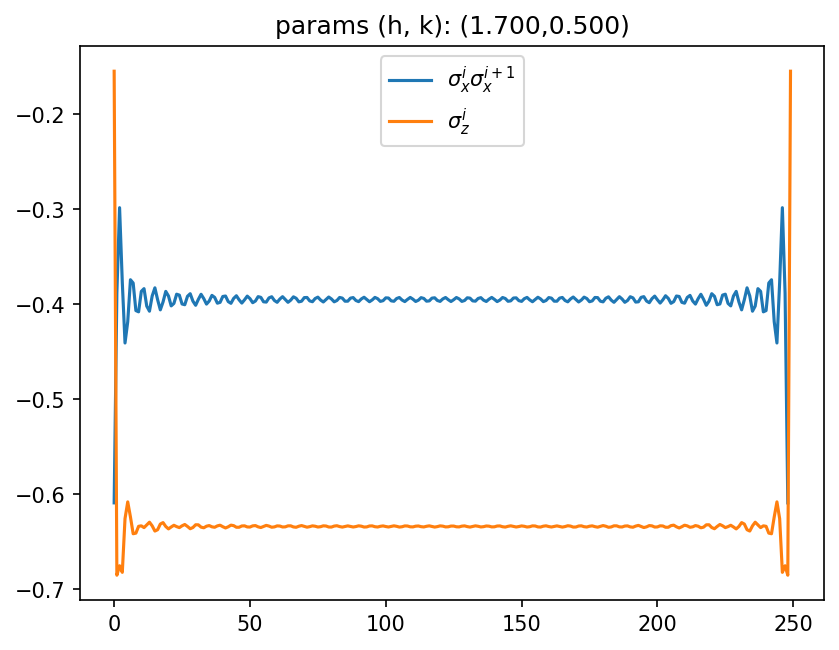

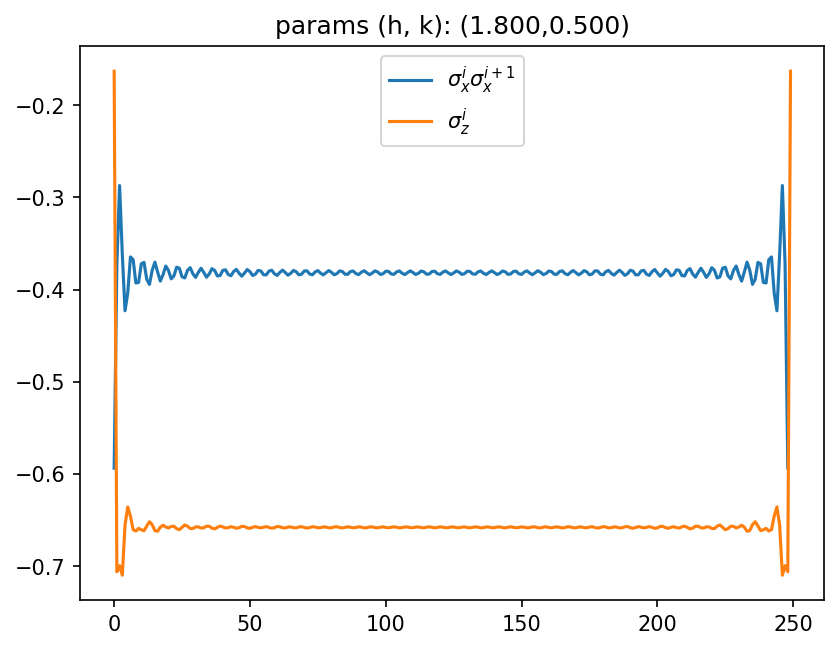

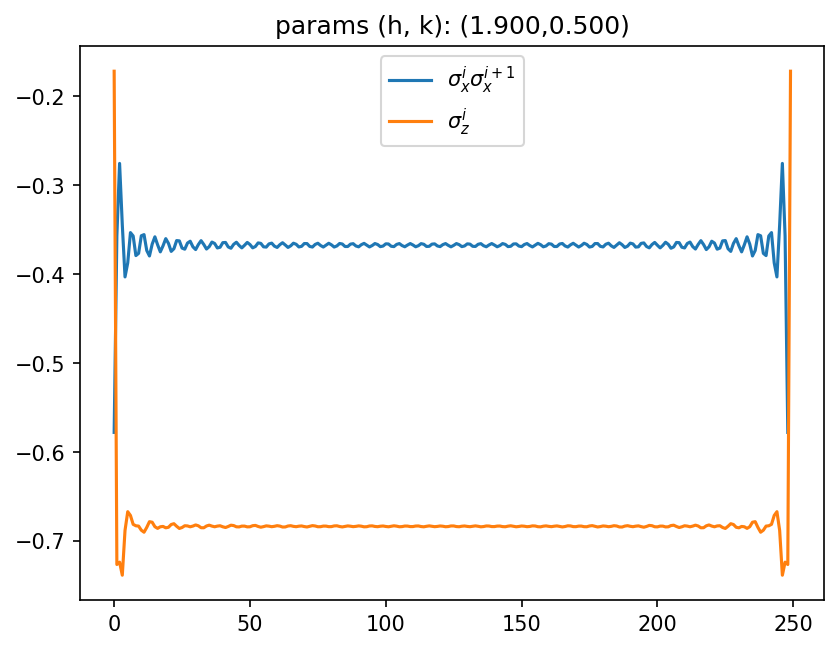

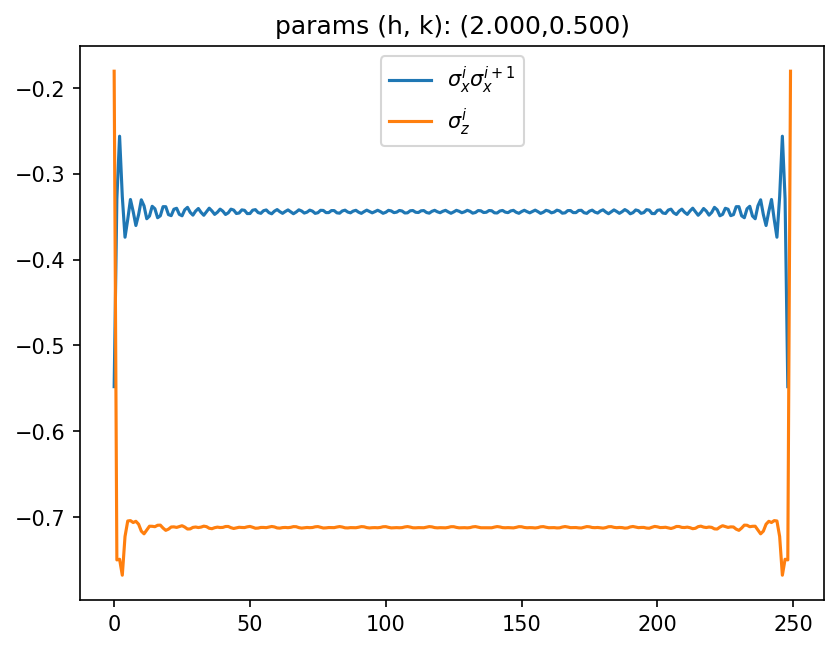

In [18]:
k=0.5
filename = os.path.join(os.getcwd(), f"L{L}-full", f"k_{k}")
plotting=True

for i in sorted(os.listdir(filename)):
    # extract magnetization values
    loc = os.path.join(filename, i)
    with open(loc, 'rb') as f:
        data = pickle.load(f)
        psi = data['psi']

    i = os.path.splitext(i)[0]
    h, k = i.split("_")[2:4] # for L250

    corr_xx = np.zeros(psi.L - 1)
    for i in range(psi.L - 1):
        # Direct two-site expectation value
        # For MPS, use expectation_value_term for efficiency
        term = [('Sigmax', i), ('Sigmax', i+1)]
        XX_val = psi.expectation_value_term(term)
        corr_xx[i] = XX_val
        
    plt.plot(corr_xx, label=r"$\sigma_x^{i}\sigma_x^{i+1}$")

    Z = psi.expectation_value("Sigmaz")

    plt.title(f"params (h, k): ({h},{k})")
    plt.plot(Z, label=r"$\sigma_z^i$")

    plt.legend()
    plt.show()


## Fitting q and K

Now that we know that we have a LL phase, we start looking for a fit of q and K.

According to bCFT, we expect Friedel Oscillations of a finite size system to follow:
$$\langle \sigma_i \rangle \propto \frac{\cos{(qi + \phi)}}{\left[(N/\pi) \cos{(\pi i/N)}\right]^K}$$

In order to get a good guess for all our parameters, we need to fit in phases - first we fit the envelope, then the oscillations. If we have the full function below:

$$\langle \sigma_i \rangle = A\frac{\cos{(qi + \phi)}}{\left[(N/\pi) \cos{(\pi i/N)}\right]^K} + B$$

We start by fitting for K, which controls the amplitudes via 

In [22]:
# onsite expectation values
k=0.5
filename = os.path.join(os.getcwd(), f"L{L}-full", f"h_{k}")
plotting=False

params = []
K = []
K_err = []
q = []
q_err = []
q_fft = []
phiz = []

for i in tqdm(sorted(os.listdir(filename))):
    # extract magnetization values
    loc = os.path.join(filename, i)
    with open(loc, 'rb') as f:
        data = pickle.load(f)
        psi = data['psi']
    i = os.path.splitext(i)[0]
    h, k = i.split("_")[2:4] # for L250
    # h, k = i.split("_")

    L = psi.L

    # for h < 1
    x = np.arange(L)
    X = psi.expectation_value("Sigmax") 

    # for h > 1
    # x = np.arange(L-1)
    # X = np.zeros(L-1)
    # for i in range(L-1):
    #     X[i] = psi.expectation_value_term([("Sigmaz", i), ("Sigmaz", i+1)])

    # cut the ends
    cut = 2
    valid = (x > cut) & (x < (L - cut))
    x = x[valid]
    X = X[valid]

    ##### fitting K ######

    # # If necessary, normalize data
    # X /= (np.max(X) - np.min(X))
    # X -= np.mean(X)

    peaks = scipy.signal.find_peaks(np.abs(X))

    if np.abs(X).size==0:
        continue
    X_peaks = [X[i] for i in peaks[0]]

    # fit those peaks to fred_two
    def fred_two(x, K):
        numerator = 1
        L = psi.L
        denominator = ((L/np.pi) * np.sin(np.pi * x / L))**K
        return (numerator/denominator)
    
    if len(X_peaks) == 0:
        continue

    popt, pcov = curve_fit(fred_two, peaks[0], np.abs(X_peaks))


    ##### Fitting q #####

    # sanitize the results, and look for q
    X_sanitized = X * ((L/np.pi) * np.sin(np.pi * x / L))**popt[0]

    peaks_length = scipy.signal.find_peaks(np.abs(X_sanitized))
    lengths = peaks_length[0]
    wavelengths = [lengths[i+1] - lengths[i] for i in range(len(lengths)-1)] 
    test_q = 0 if len(wavelengths)==0 else np.pi / np.mean(wavelengths)

    def fred_one(x,A,q,phi):
        return A * np.abs(np.cos(q*x + phi))

    popt1, pcov1 = curve_fit(fred_one, x, np.abs(X_sanitized),
                            bounds=([-1, 0, 0],[1, 2*np.pi, L]),
                            p0=[1, np.pi-test_q, test_q/np.pi])

    ##### Reproducing X #####
    def friedel_oscillations(x, A, B, phi, L, q, K):
        numerator = np.cos(q * x + phi)
        denominator = ((L/np.pi ) * np.sin(np.pi * x / L))**K
        return A * (numerator/denominator) + B

    # -- Check for A -- #
    def friedel_core(x, q, phi, L, K):
        return np.cos(q * x + phi) / (((L/np.pi) * np.sin(np.pi * x / L))**K)

    model_core = friedel_core(x, popt1[1], popt1[2], L, popt[0])

    res_plus  = np.sum(( X - (+1) * model_core )**2)
    res_minus = np.sum(( X - (-1) * model_core )**2)

    A = +1 if res_plus < res_minus else -1

    # save and move on
    params.append(float(h))
    K.append(popt[0])
    K_err.append(pcov[0][0])
    q.append(popt1[1])
    q_err.append(pcov1[1][1])
    phiz.append(popt1[2])

    # Check Fourier Transform

    X_fft = np.fft.fftshift(np.fft.fft(X))
    freqs = np.fft.fftshift(np.fft.fftfreq(len(X_fft), d=1)) * 2

    leading_freqs = scipy.signal.find_peaks(X_fft)
    leading_freqs = leading_freqs[0]  
    leader = 1 if len(leading_freqs) == 0 else leading_freqs[-1]  
    q_fft.append(freqs[leader])
    
    #### - Plotting - #####
    if plotting:
        fig, ax = plt.subplots(1, 4, figsize=(28, 7))
        fig.suptitle(f"Fitting for {h}, {k}")

        ax[0].plot(x, np.abs(X), label=f"X, {h}, {k}")
        ax[0].scatter(peaks[0]+cut, np.abs(X_peaks), label="peaks")
        ax[0].plot(x, (fred_two(x, *popt)), label=f"fit, K={popt[0]}")
        ax[0].set_title("Fitting for K")

        ax[1].set_title("fitting peaks for q")
        ax[1].plot(x, np.abs(X_sanitized), label="Sanitized X")
        ax[1].scatter(peaks_length[0]+cut, np.abs(X_sanitized)[peaks_length[0]], label="peaks")
        ax[1].plot(x, fred_one(x, *popt1), label=f"fit, q={q}")

        ax[2].set_title("Reproducing <X>")
        ax[2].scatter(x, X, marker="x")
        ax[2].scatter(x, friedel_oscillations(x, A, 0, popt1[2], L, popt1[1], popt[0]), alpha=0.7, label=f"K={popt[0]}, q={popt1[1]/np.pi}")

        ax[3].set_title("Fourier Transform")
        ax[3].plot(freqs, X_fft)
        ax[3].scatter(freqs[leading_freqs], X_fft[leading_freqs], label=f"{freqs[leading_freqs]}")

        plt.xlabel("site")
        plt.ylabel("onsite expectation value")
        plt.legend()
        plt.show()


  0%|          | 0/26 [00:00<?, ?it/s]/home/silvanita/Desktop/thesis/master_thesis/ed_venv/lib/python3.12/site-packages/scipy/signal/_peak_finding.py:266: ComplexWarning: Casting complex values to real discards the imaginary part
  value = np.asarray(value, order='C', dtype=np.float64)
100%|██████████| 26/26 [02:08<00:00,  4.95s/it]


Text(0.5, 1.0, 'Wavevector q for h = 0.500')

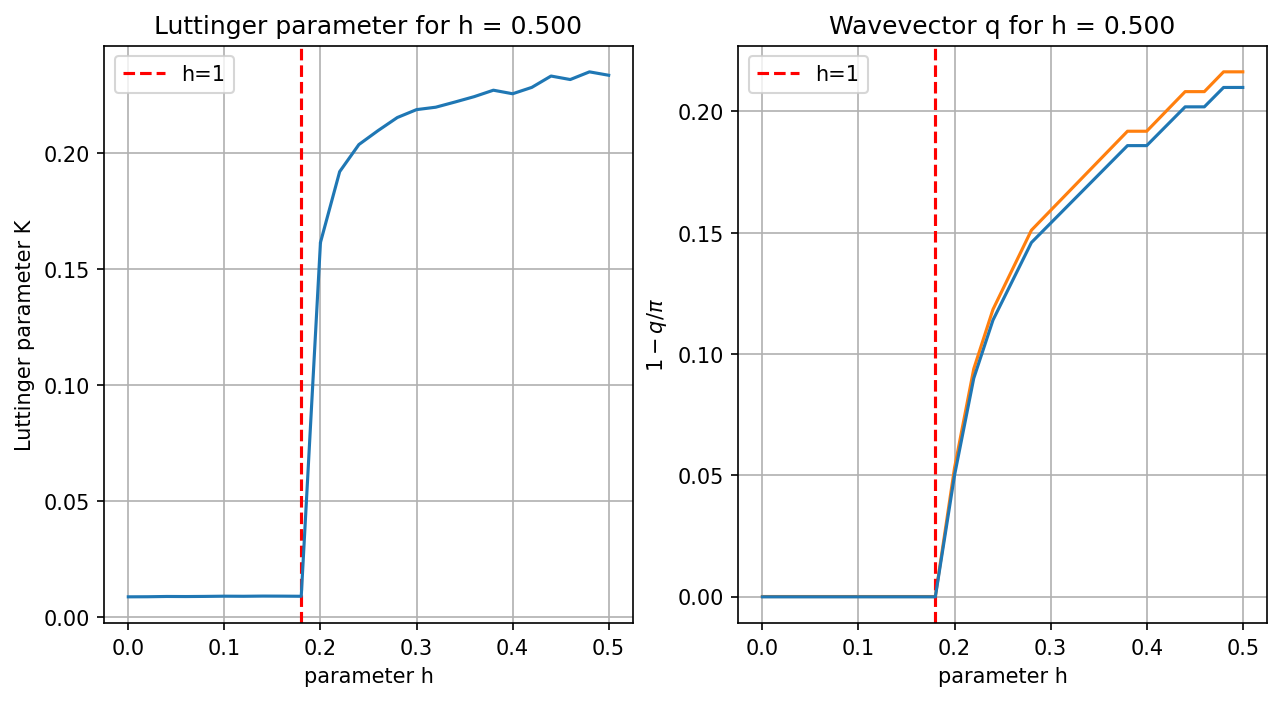

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))
q_fft_copy = q_fft
for i in range(10):
    q_fft_copy[i] = 1

params = np.arange(0, 0.51, 0.02)

ax[0].errorbar(params, K, K_err)
ax[0].axvline(0.18, ls = "--", c='red', label = "h=1")
ax[0].grid()
ax[0].legend()
ax[0].set_xlabel("parameter h")
ax[0].set_ylabel("Luttinger parameter K")
ax[0].set_title(f"Luttinger parameter for h = {h}")

ax[1].errorbar(params, 1-np.array(q)/np.pi, q_err)
ax[1].plot(params, 1-np.array(q_fft_copy))
ax[1].axvline(0.18, ls = "--", c='red',label = "h=1")
ax[1].grid()
ax[1].legend()
ax[1].set_xlabel("parameter h")
ax[1].set_ylabel(r"$1 - q / \pi$")
ax[1].set_title(f"Wavevector q for h = {h}")

## Correlation Functions

/home/ioannisangelotassioulas/Documents/master_thesis/books/L250-full/k_0.5


  0%|          | 0/21 [00:00<?, ?it/s]

dmrg_250_0.000_0.500_0.500_1.000.pkl


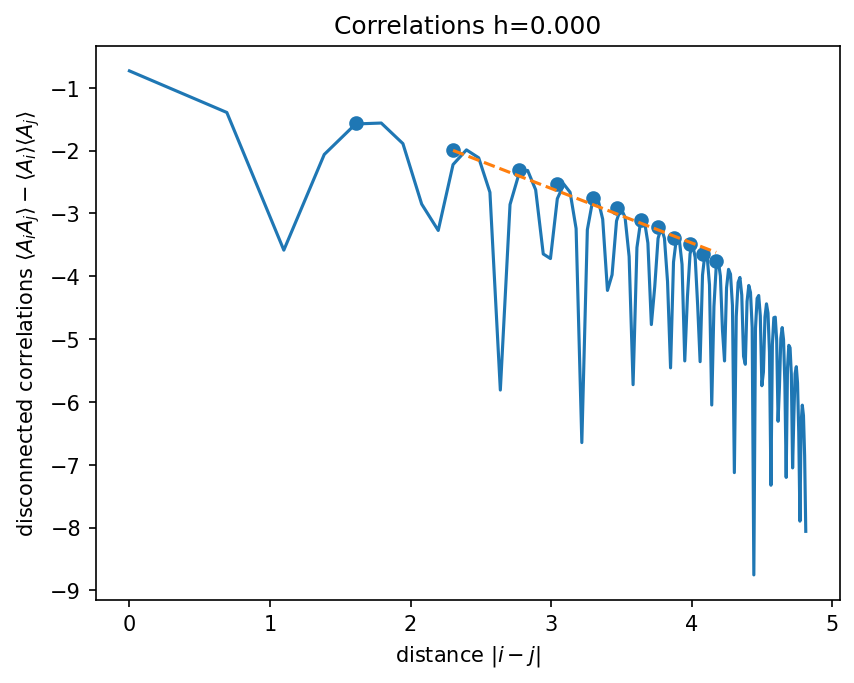

  5%|▍         | 1/21 [00:20<06:48, 20.45s/it]

dmrg_250_0.100_0.500_0.500_1.000.pkl


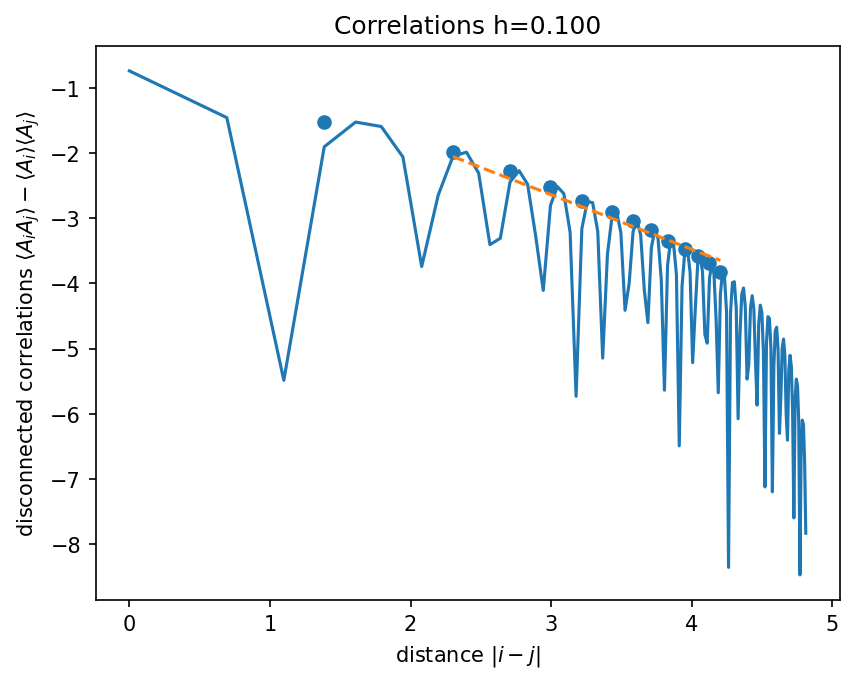

 10%|▉         | 2/21 [00:41<06:35, 20.84s/it]

dmrg_250_0.200_0.500_0.500_1.000.pkl


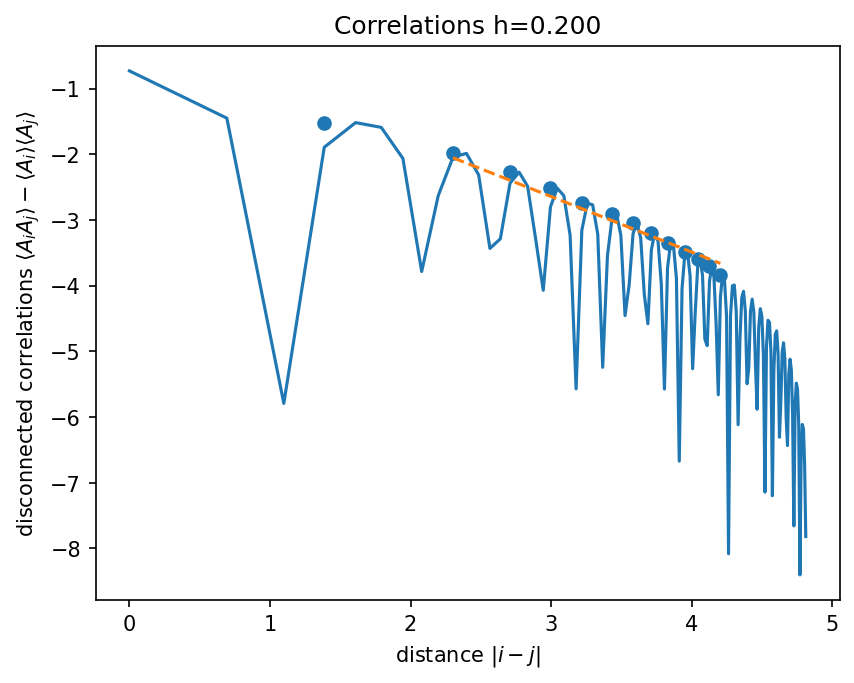

 14%|█▍        | 3/21 [01:01<06:05, 20.30s/it]

dmrg_250_0.300_0.500_0.500_1.000.pkl


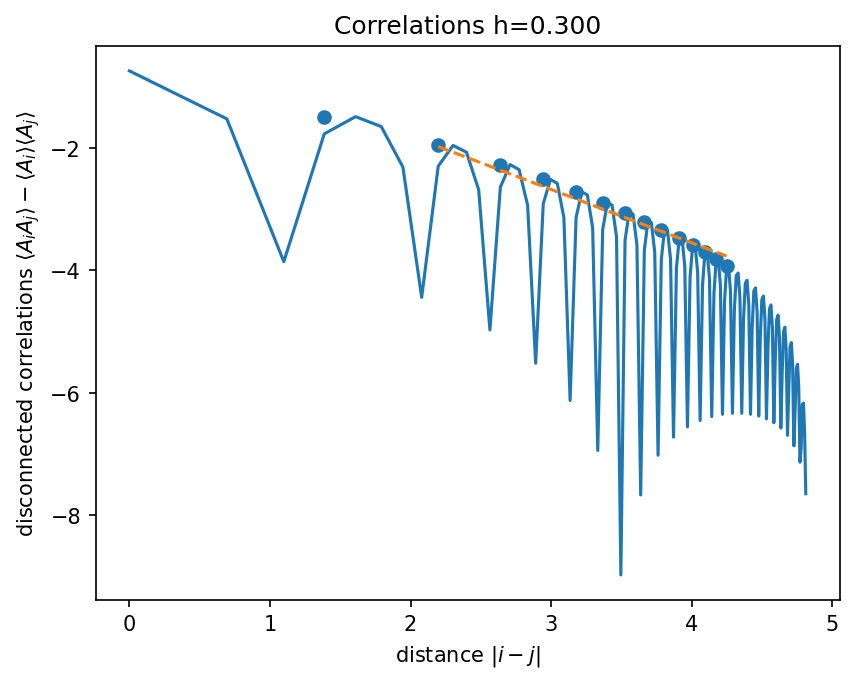

 19%|█▉        | 4/21 [01:19<05:31, 19.51s/it]

dmrg_250_0.400_0.500_0.500_1.000.pkl


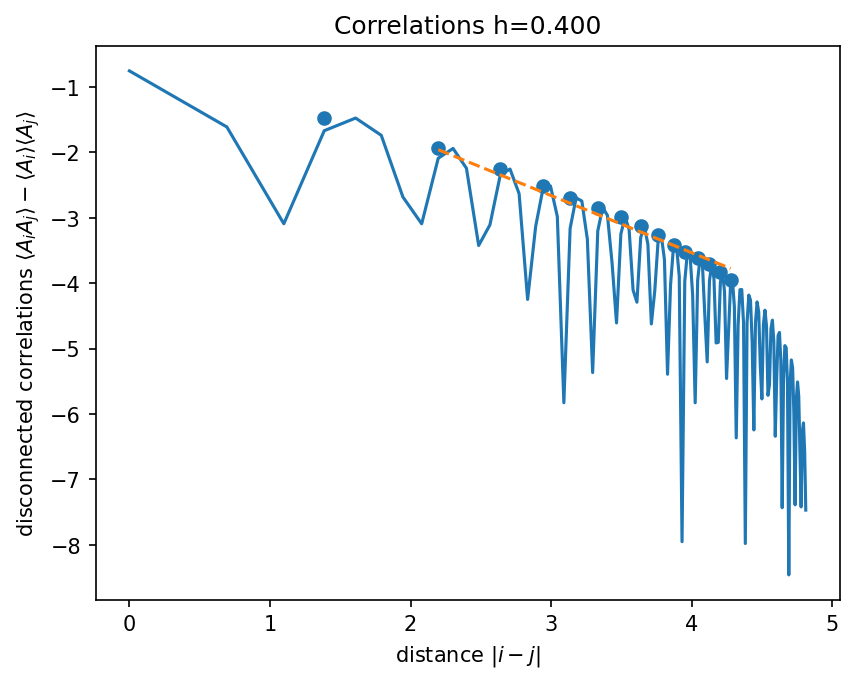

 24%|██▍       | 5/21 [01:38<05:09, 19.34s/it]

dmrg_250_0.500_0.500_0.500_1.000.pkl


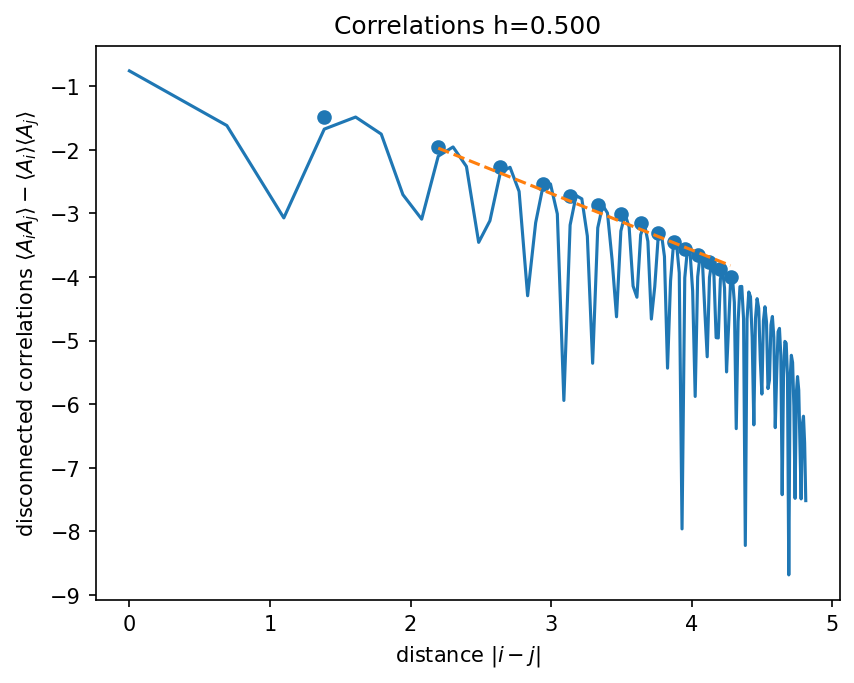

 29%|██▊       | 6/21 [01:58<04:52, 19.51s/it]

dmrg_250_0.600_0.500_0.500_1.000.pkl


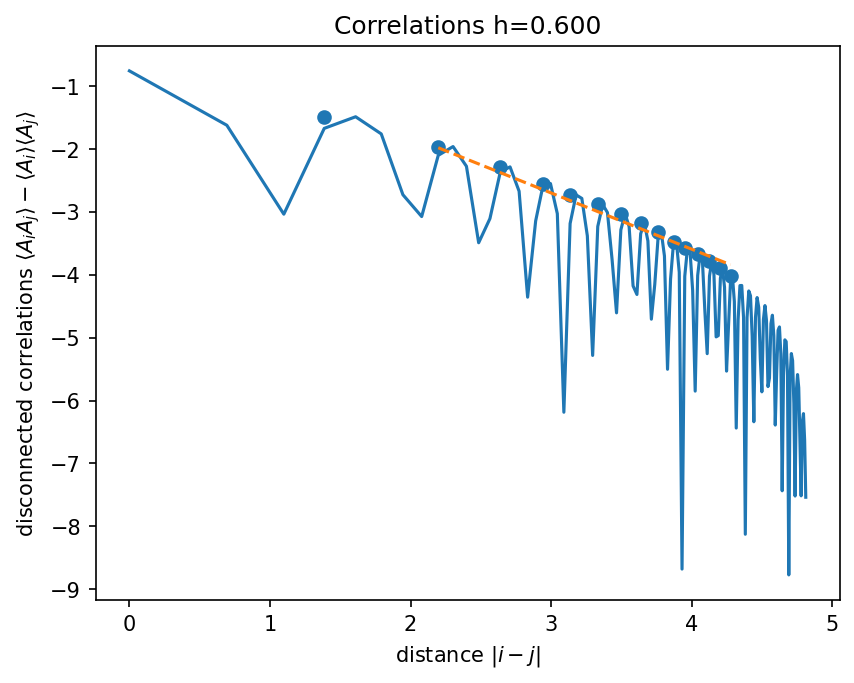

 33%|███▎      | 7/21 [02:18<04:33, 19.57s/it]

dmrg_250_0.700_0.500_0.500_1.000.pkl


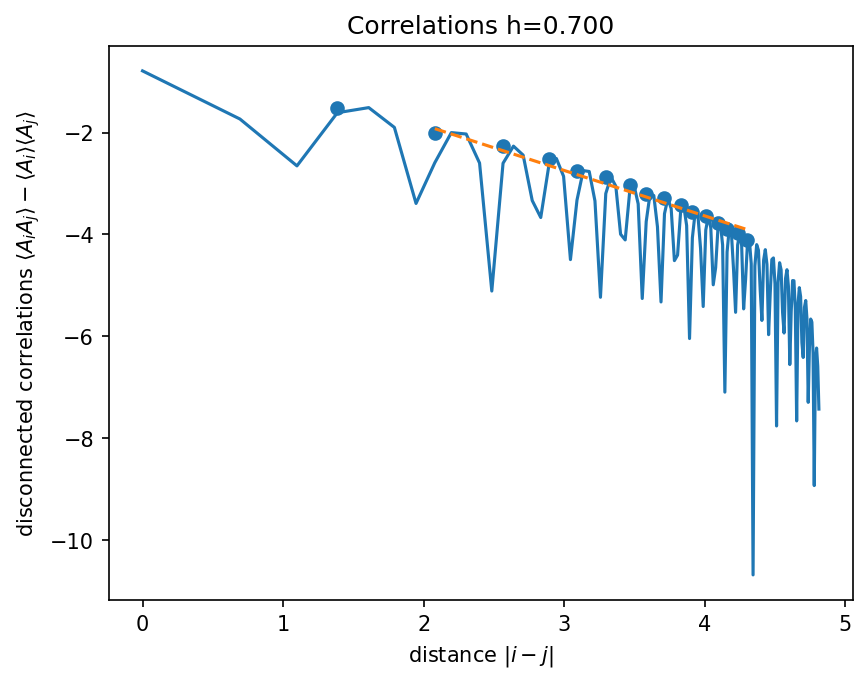

 38%|███▊      | 8/21 [02:38<04:16, 19.73s/it]

dmrg_250_0.800_0.500_0.500_1.000.pkl


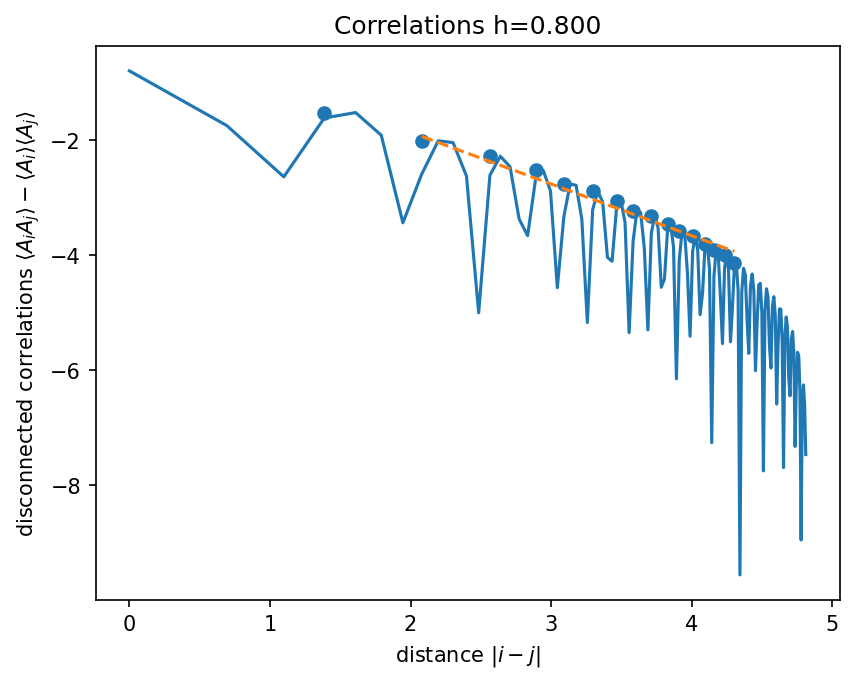

 43%|████▎     | 9/21 [02:58<03:57, 19.82s/it]

dmrg_250_0.900_0.500_0.500_1.000.pkl


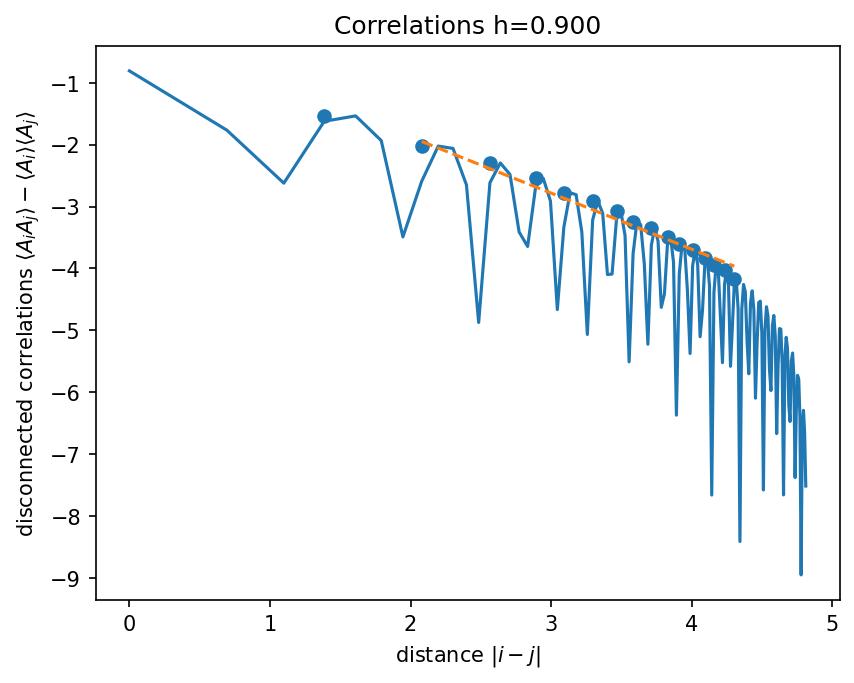

 48%|████▊     | 10/21 [03:18<03:40, 20.06s/it]

dmrg_250_1.000_0.500_0.500_1.000.pkl


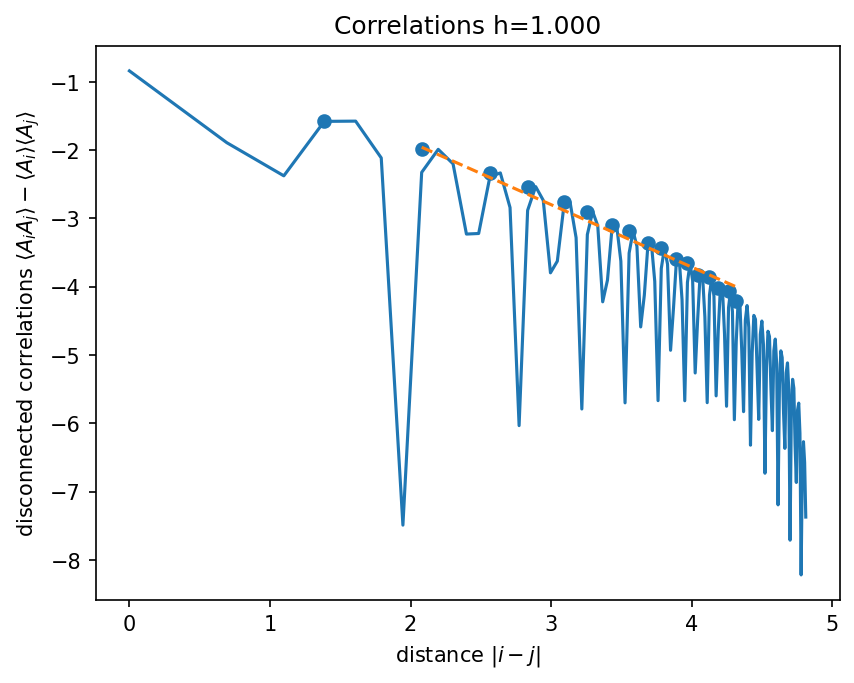

 52%|█████▏    | 11/21 [03:38<03:19, 19.99s/it]

dmrg_250_1.100_0.500_0.500_1.000.pkl


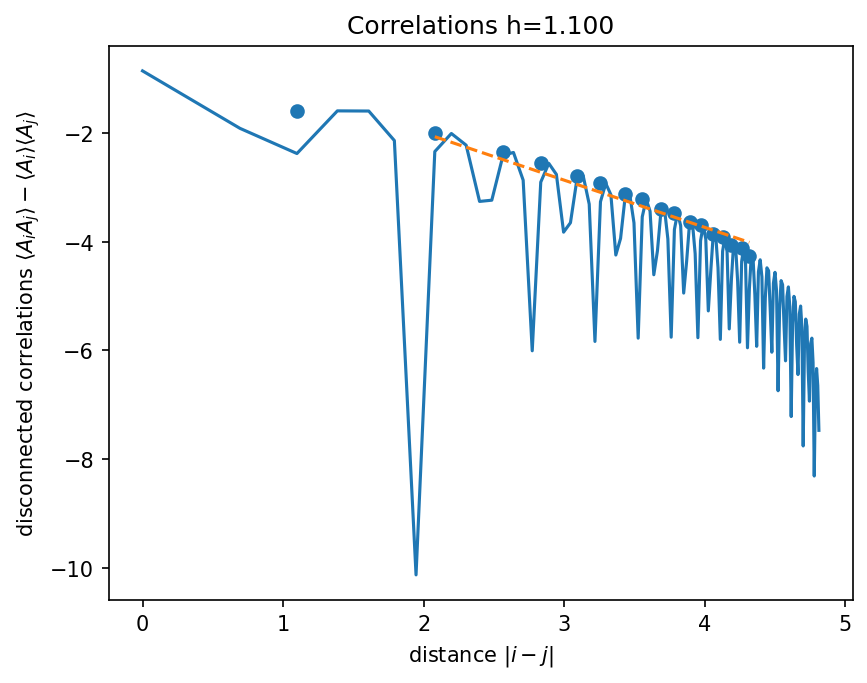

 57%|█████▋    | 12/21 [03:57<02:56, 19.64s/it]

dmrg_250_1.200_0.500_0.500_1.000.pkl


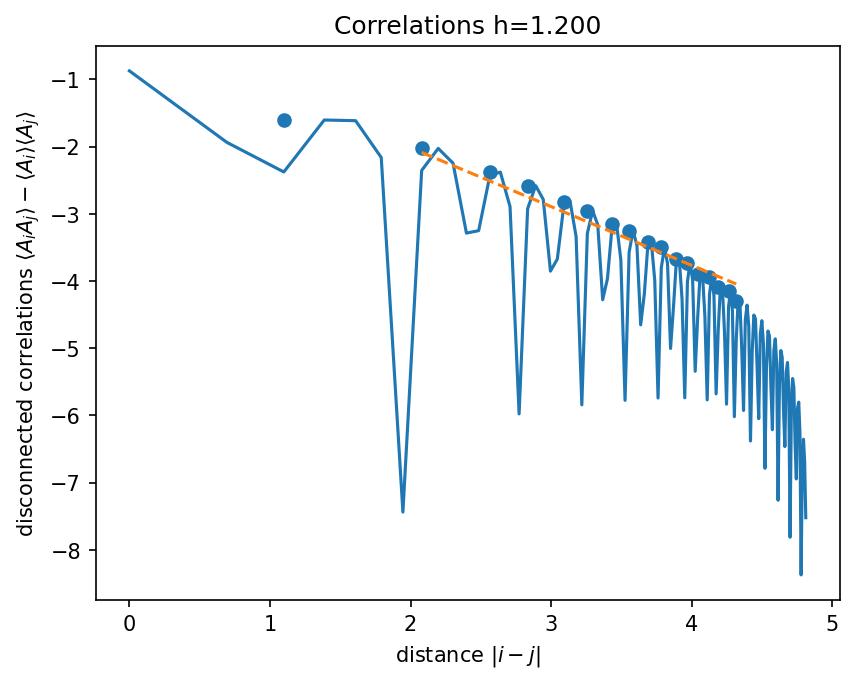

 62%|██████▏   | 13/21 [04:18<02:39, 19.92s/it]

dmrg_250_1.300_0.500_0.500_1.000.pkl


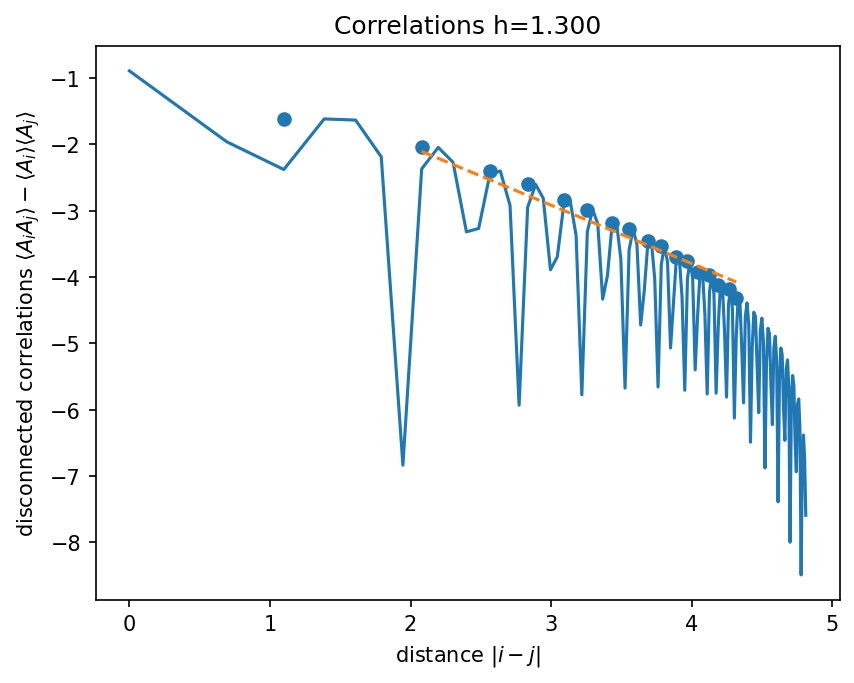

 67%|██████▋   | 14/21 [04:37<02:17, 19.68s/it]

dmrg_250_1.400_0.500_0.500_1.000.pkl


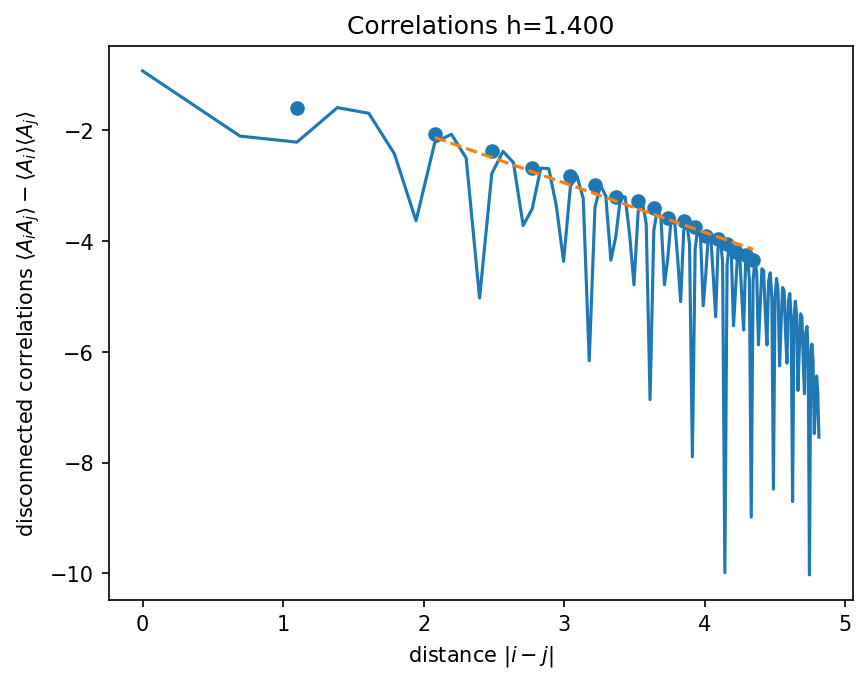

 71%|███████▏  | 15/21 [04:58<02:01, 20.20s/it]

dmrg_250_1.500_0.500_0.500_1.000.pkl


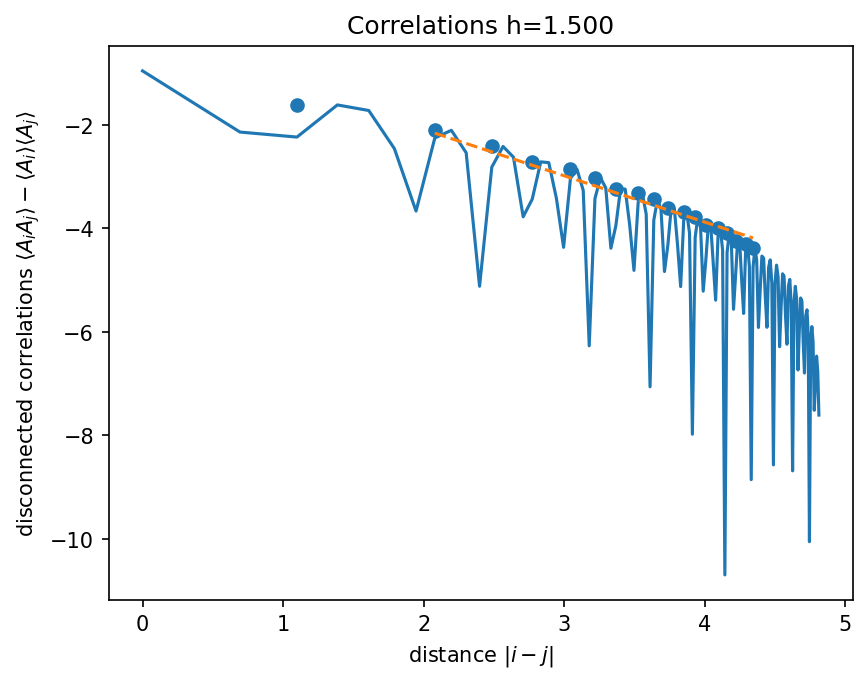

 76%|███████▌  | 16/21 [05:20<01:42, 20.60s/it]

dmrg_250_1.600_0.500_0.500_1.000.pkl


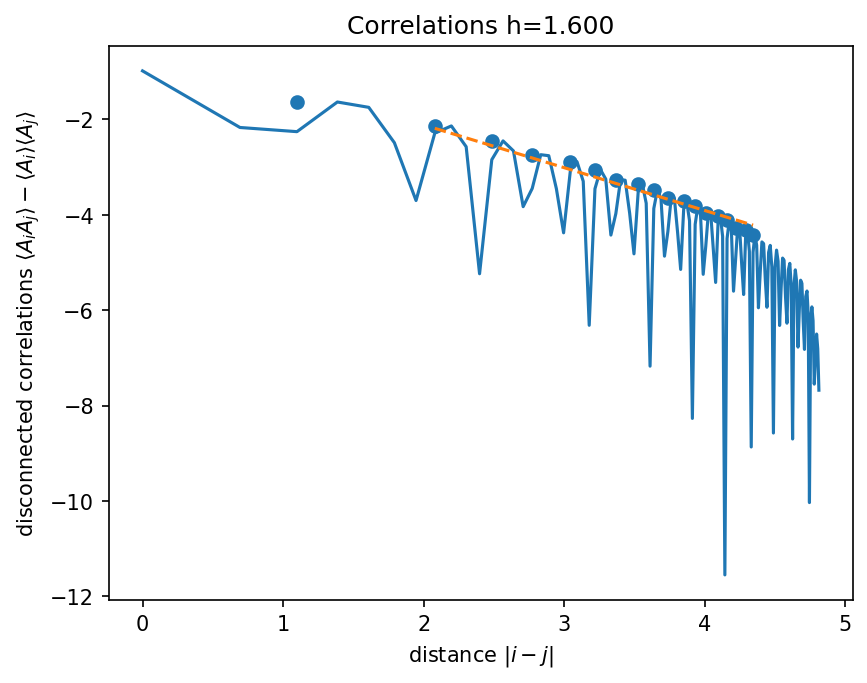

 81%|████████  | 17/21 [05:39<01:20, 20.18s/it]

dmrg_250_1.700_0.500_0.500_1.000.pkl


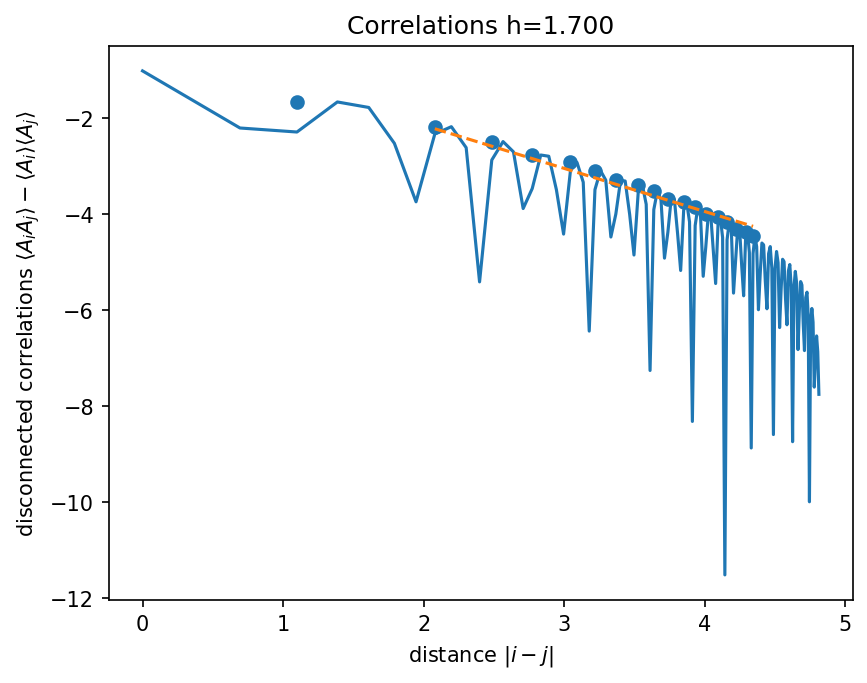

 86%|████████▌ | 18/21 [05:57<00:58, 19.63s/it]

dmrg_250_1.800_0.500_0.500_1.000.pkl


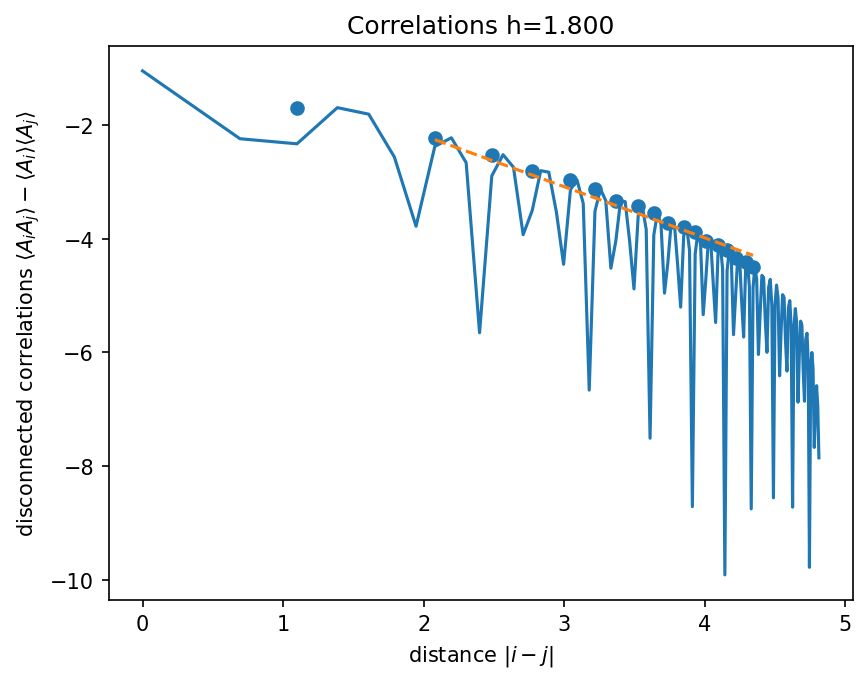

 90%|█████████ | 19/21 [06:18<00:39, 19.86s/it]

dmrg_250_1.900_0.500_0.500_1.000.pkl


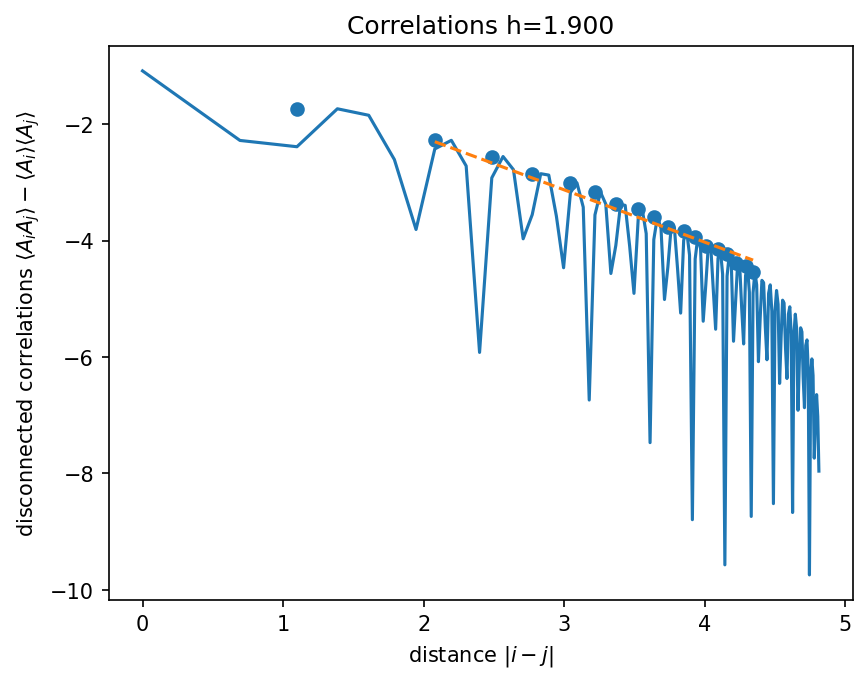

 95%|█████████▌| 20/21 [06:37<00:19, 19.82s/it]

dmrg_250_2.000_0.500_0.500_1.000.pkl


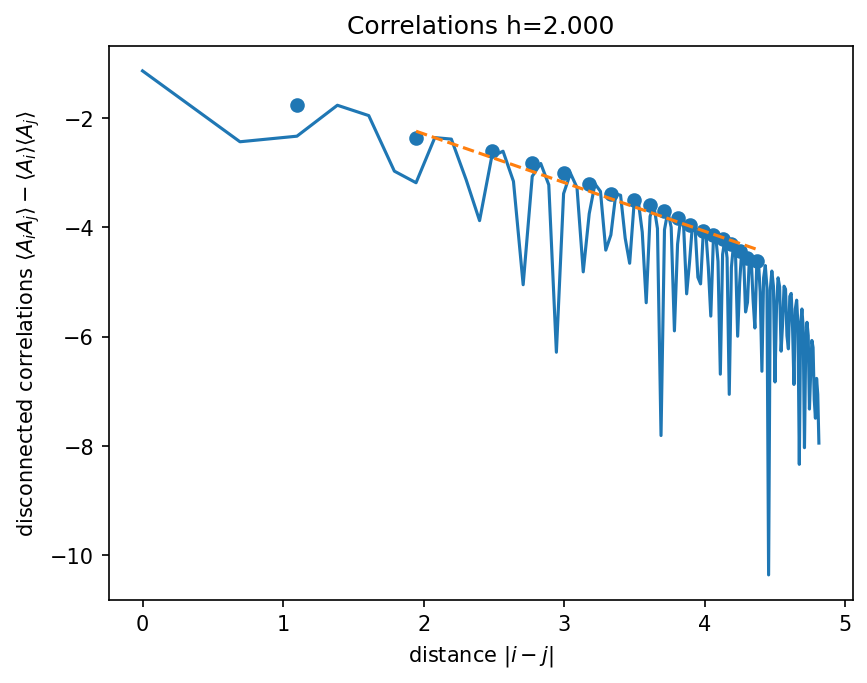

100%|██████████| 21/21 [06:58<00:00, 19.94s/it]


In [23]:
# correlation functions
from tqdm import tqdm
h=0.5
jump=0

filename = os.path.join(filename_master, f"k_{h}")
print(filename)

plt.figure()

def linfun(x, A, b):
    return A * x + b
xi = []
ks = []
for i in tqdm(sorted(os.listdir(filename), key = lambda x: float(x.split("_")[2]))):
    print(i)
    loc = os.path.join(filename, i)
    with open(loc, 'rb') as f:
        data = pickle.load(f)
        psi = data['psi']
    
    i = os.path.splitext(i)[0]
    h, k = i.split("_")[2:4]

    if jump <= 0:
        i0 = psi.L // 2  # for fixed `i` 
        j = np.arange(i0 + 1, psi.L-1)
        dx = j - i0

        X = psi.expectation_value("Sigmax")
        Y = psi.expectation_value("Sigmax")
        XX = psi.term_correlation_function_right([("Sigmax", 0)], [("Sigmax", 0)], i_L=i0, j_R=j)
        XX_disc = XX - X[i0] * Y[j]

        plt.plot(np.log(dx), np.log(np.abs(XX_disc)), label=f"{h}, {k}")
        cut_for_fit = 10

        # PLOT ONLY THE TOP ONES
        peaks, _ = scipy.signal.find_peaks(np.abs(XX_disc))
        corr_peaks = XX_disc[peaks]
        plt.scatter(np.log(peaks[:-cut_for_fit]), np.log(np.abs(corr_peaks[:-cut_for_fit])))

        # fit lin
        try:
            popt, pcov = curve_fit(linfun, np.log(peaks[:-cut_for_fit]), np.log(np.abs(corr_peaks[:-cut_for_fit])))
        except TypeError:
            continue
        plt.plot(np.log(peaks[1:-cut_for_fit]), linfun(np.log(peaks[1:-cut_for_fit]), *popt), ls="--")
        ks.append(float(k))
        xi.append(-1/popt[0])

    if jump > 0:
        valid_sites = np.arange(psi.L - jump)
        i0 = (psi.L-jump)// 2
        j = np.arange(i0 + jump + 1, psi.L - jump)
        dx = j - i0

        XY = psi.correlation_function(  # i0 is constant (middle) so we just take it as a scalar
            "Sigmax", "Sigmay",
            sites1=i0,
            sites2=i0 + jump
        )[0,0] # force scalar

        XY_prime = np.array([  # j is a list of indices
            psi.correlation_function("Sigmax", "Sigmay", [j_], [j_ + jump])
            for j_ in j
        ]).flatten()

        XYXY = psi.term_correlation_function_right(  # hold i, sweep j for XYXY
            [("Sigmax", 0), ("Sigmay", jump)],
            [("Sigmax", 0), ("Sigmay", jump)],
            i_L=i0,
            j_R=j
        )

        XYXY_conn = XYXY - XY*XY_prime

        plt.plot(dx, np.abs(XYXY_conn), label=f"{h}, {k}")
    plt.xlabel(r"distance $|i-j|$")
    plt.ylabel(r"disconnected correlations $\langle A_i A_j\rangle - \langle A_i \rangle\langle A_j\rangle$")
    plt.title(f"Correlations h={h}")
    # plt.legend()
    # plt.semilogy()
    plt.show()


## Entanglement Entropy

In [ ]:
h_range = [0.5]
for h in h_range:
    plt.figure(figsize=(10,5))

    mid_chain_entropy = []
    ks = []
    sim = f"k_{h}"
    filename = os.path.join(os.getcwd(), "L250-full", sim)
    for i in sorted(os.listdir(filename)):
        j=os.path.splitext(i)[0]
        h, k = j.split("_")[2:4]
        loc = os.path.join(filename, i)
        with open(loc, 'rb') as f:
            data = pickle.load(f)
            psi = data['psi']

        L = psi.L
        S = psi.entanglement_entropy()

        ks.append(float(h))
        mid_chain_entropy.append(S[L//2])
    plt.plot(ks,mid_chain_entropy, marker="x", alpha=0.6, label=f"k={k}")
    plt.xticks(ks[::2])
    plt.legend()
    plt.grid()
    plt.show()

extraced central charge 0.98001 with residuum 4.73e-03


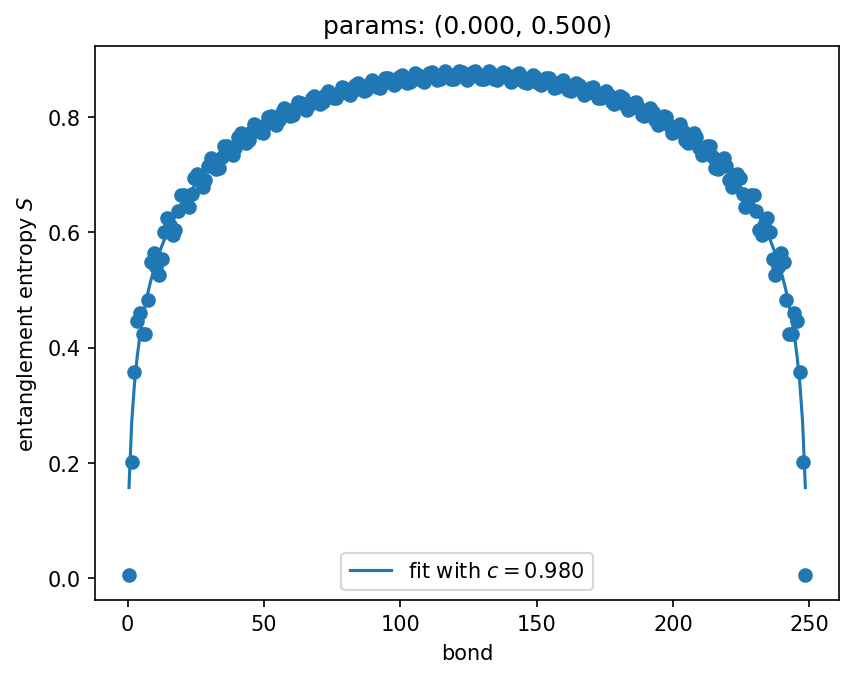

extraced central charge 1.00786 with residuum 3.14e-03


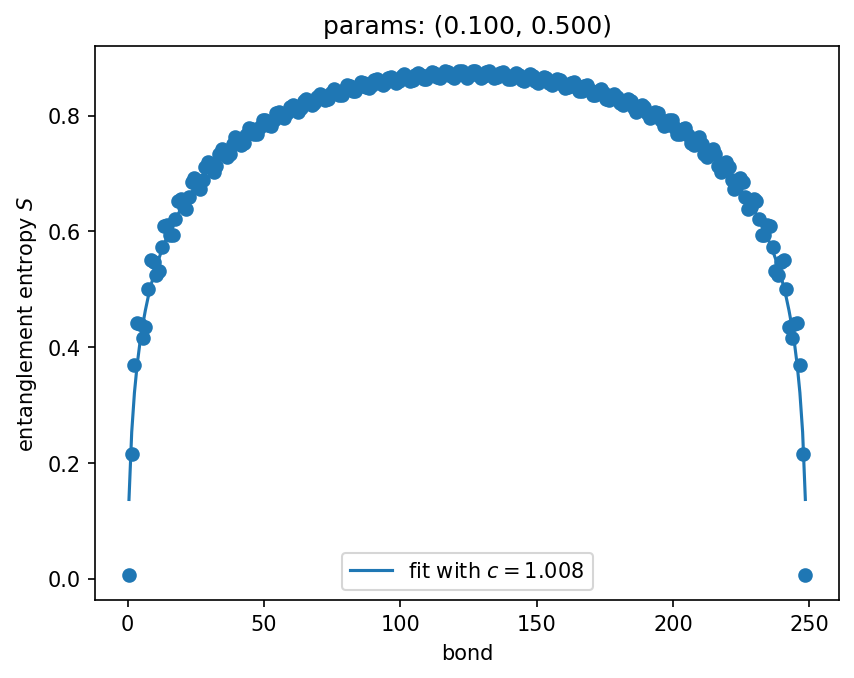

extraced central charge 1.00679 with residuum 2.62e-03


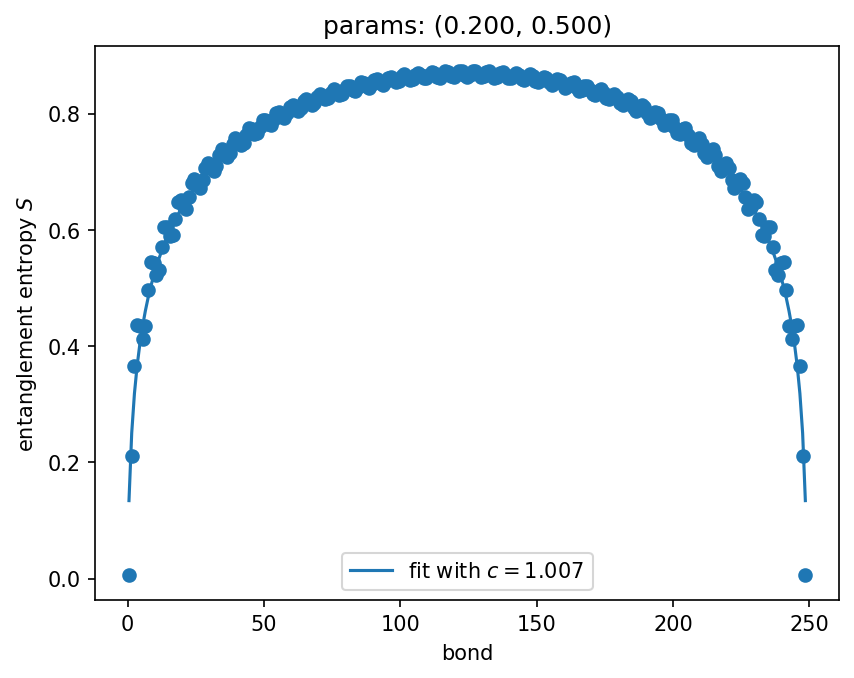

extraced central charge 0.98699 with residuum 1.72e-03


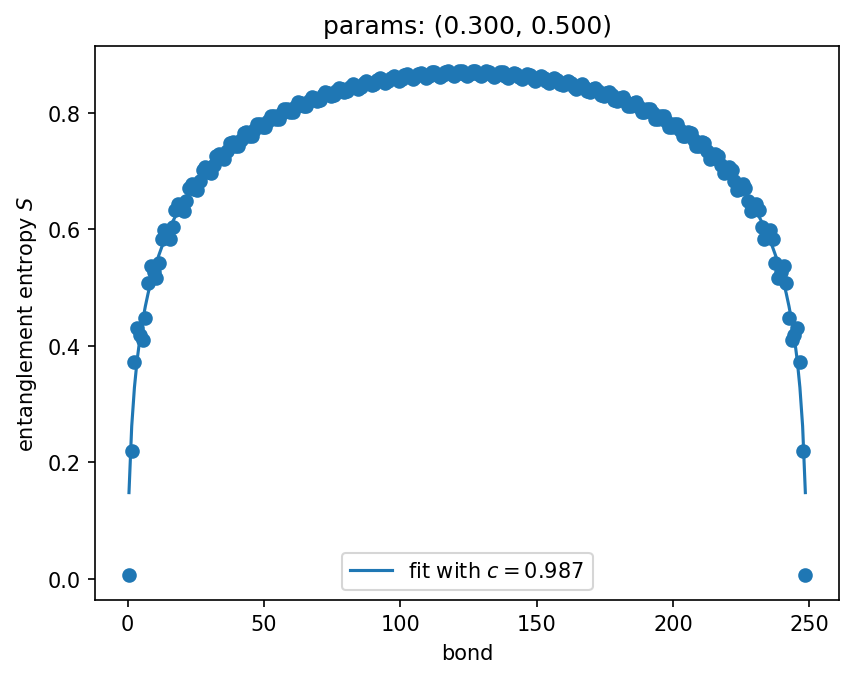

extraced central charge 1.02489 with residuum 1.12e-03


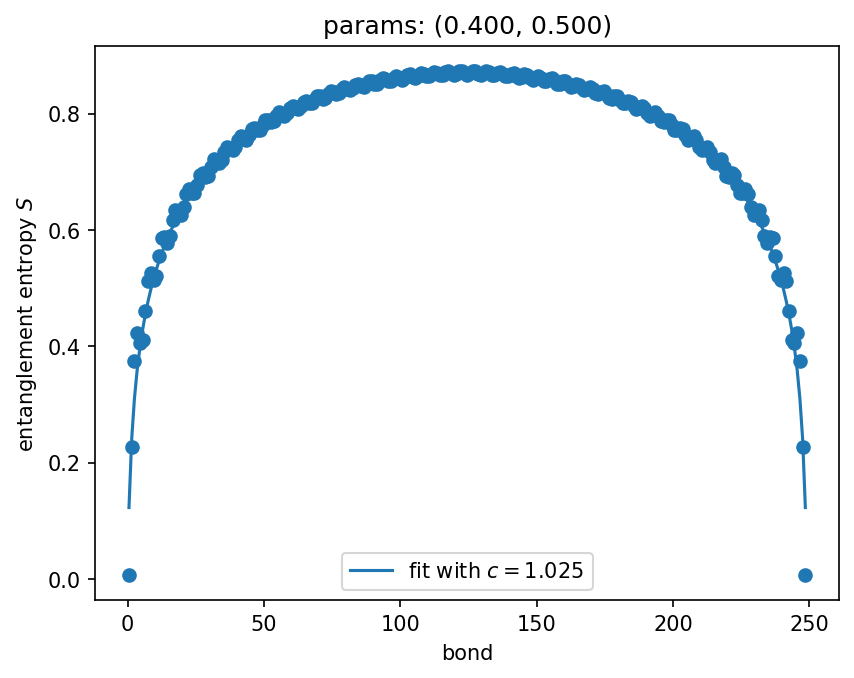

extraced central charge 1.00201 with residuum 9.67e-04


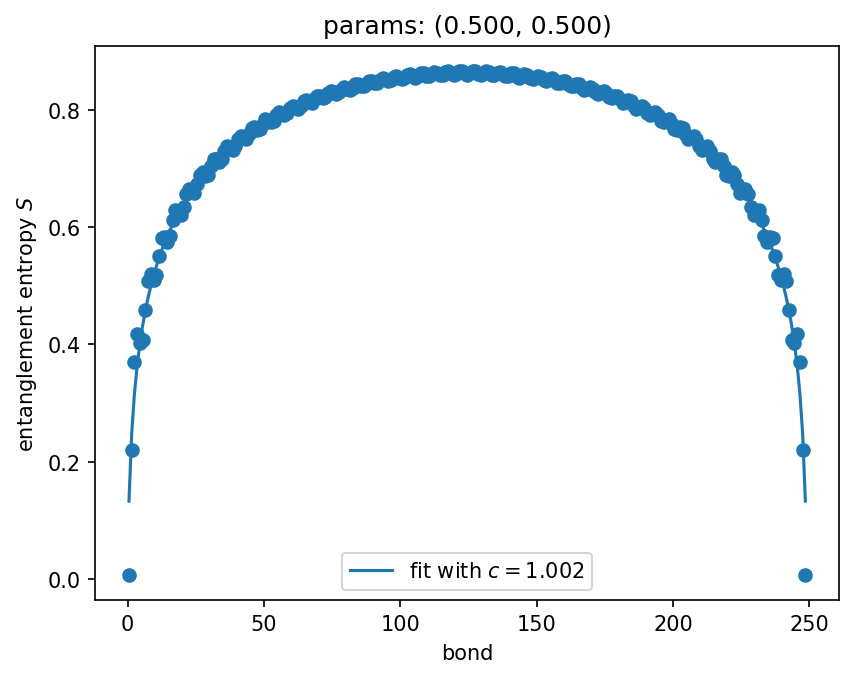

extraced central charge 1.00164 with residuum 8.42e-04


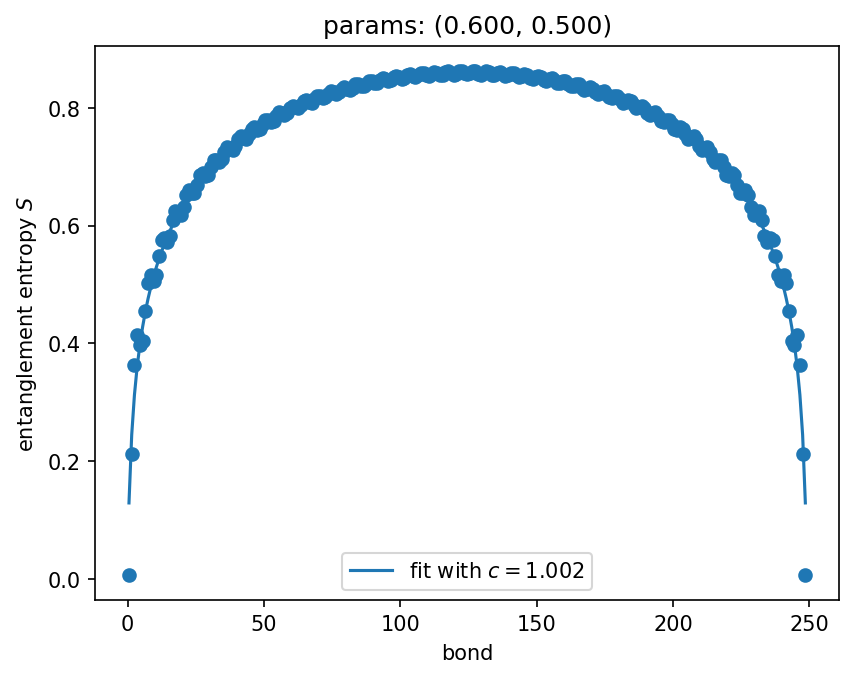

extraced central charge 0.99148 with residuum 5.72e-04


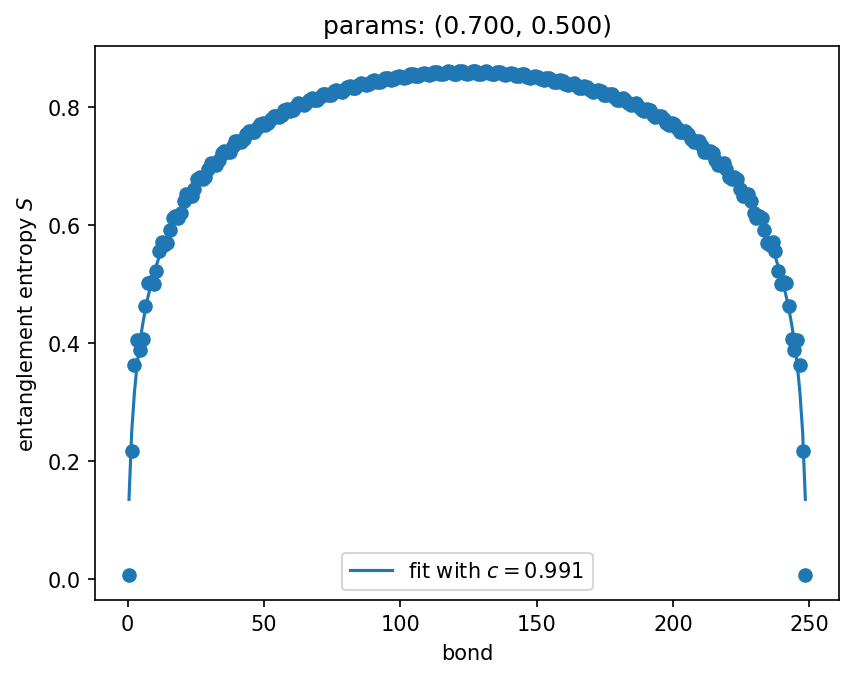

extraced central charge 0.99213 with residuum 5.19e-04


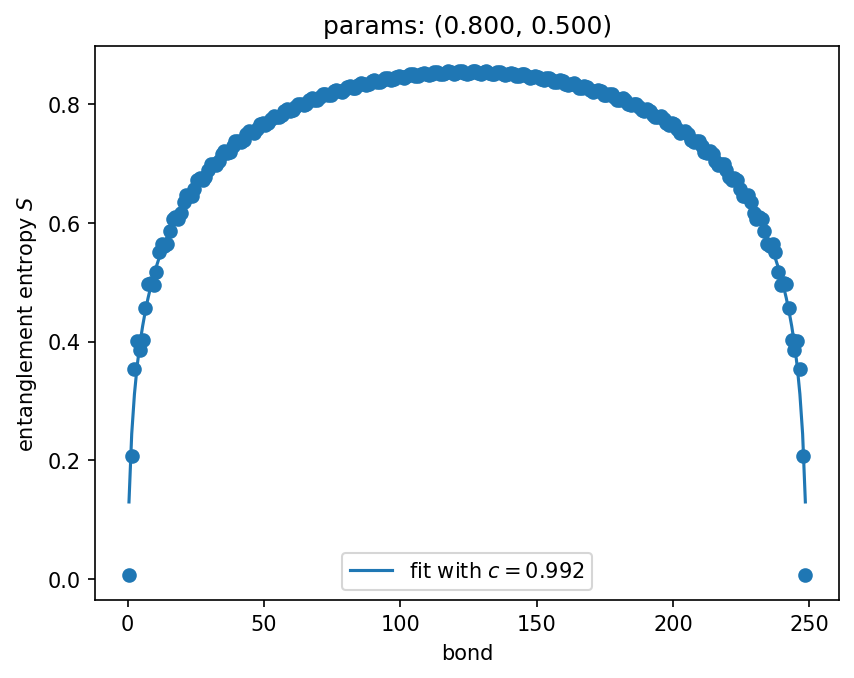

extraced central charge 0.99370 with residuum 5.05e-04


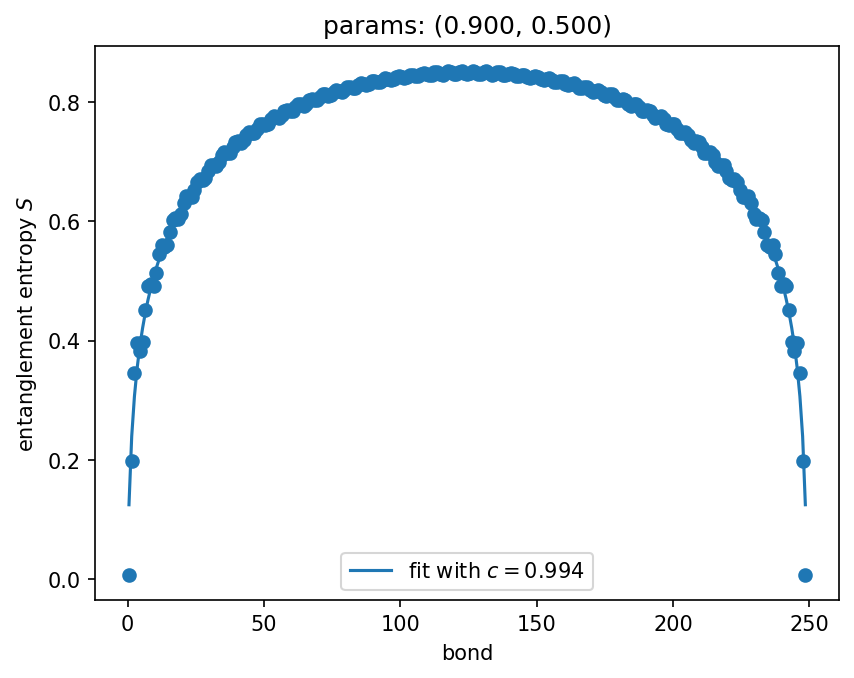

extraced central charge 1.00864 with residuum 4.51e-04


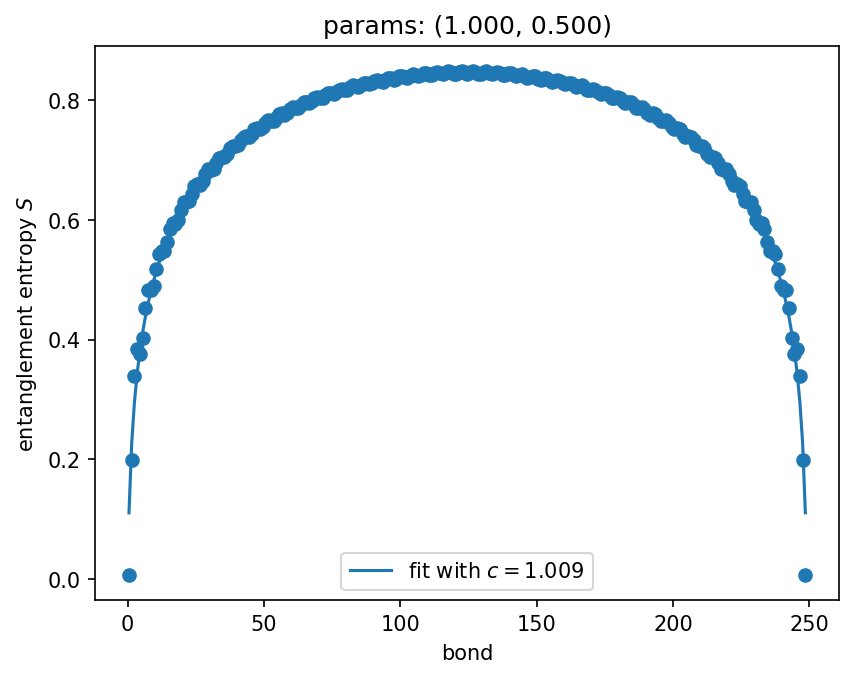

extraced central charge 0.99725 with residuum 3.77e-04


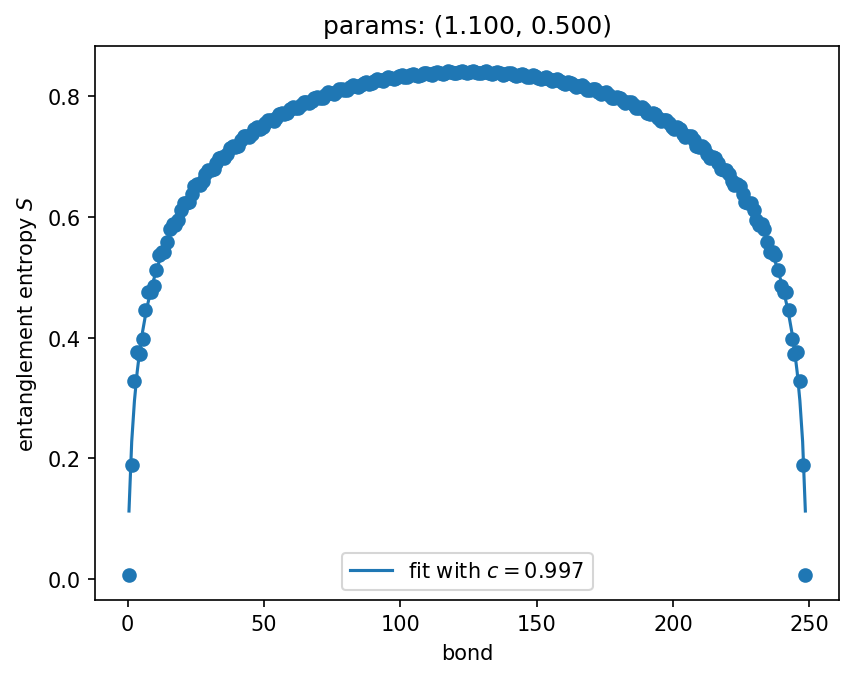

extraced central charge 0.99826 with residuum 3.24e-04


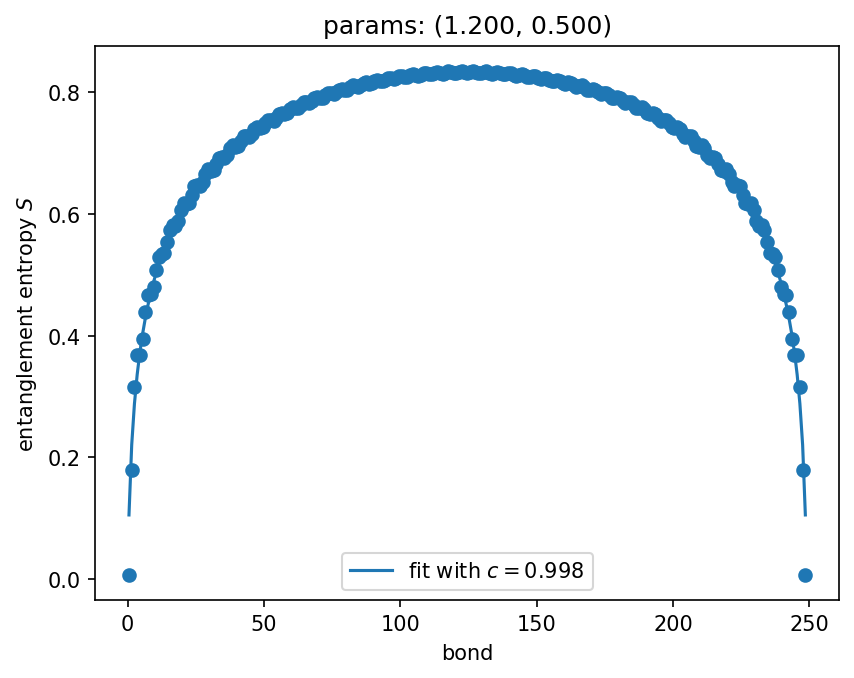

extraced central charge 0.99961 with residuum 3.02e-04


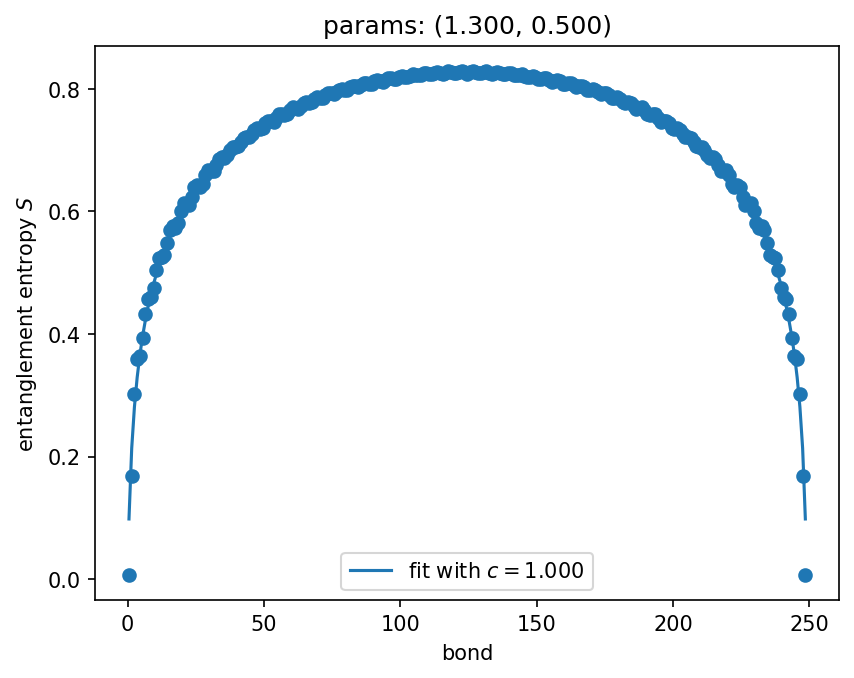

extraced central charge 0.98980 with residuum 2.60e-04


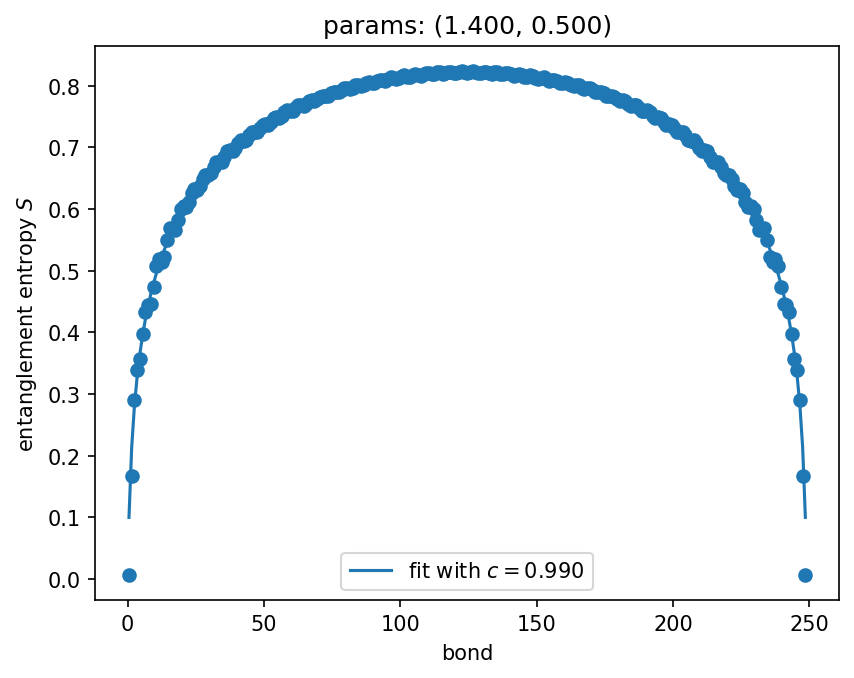

extraced central charge 0.98949 with residuum 2.42e-04


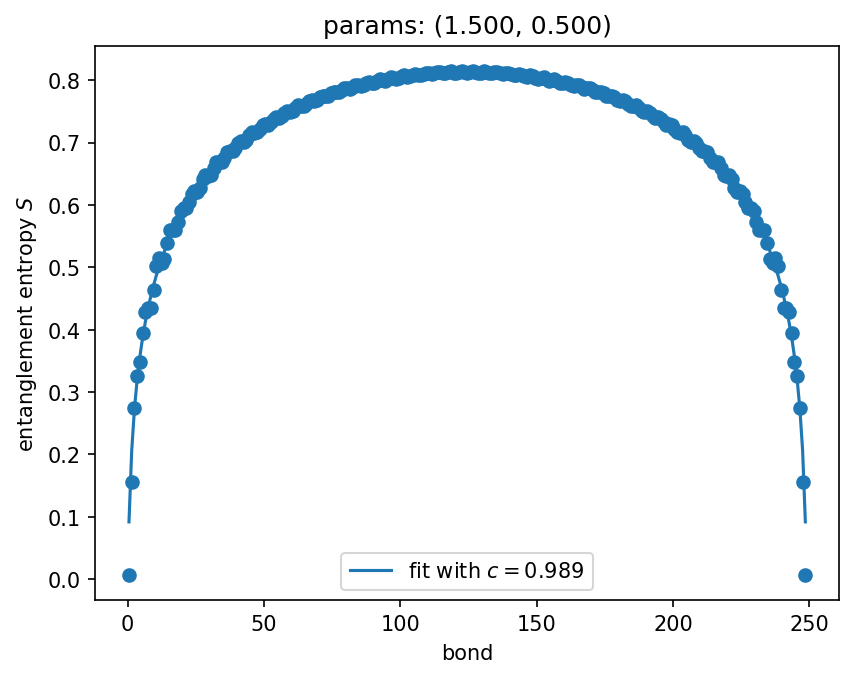

extraced central charge 0.98885 with residuum 2.20e-04


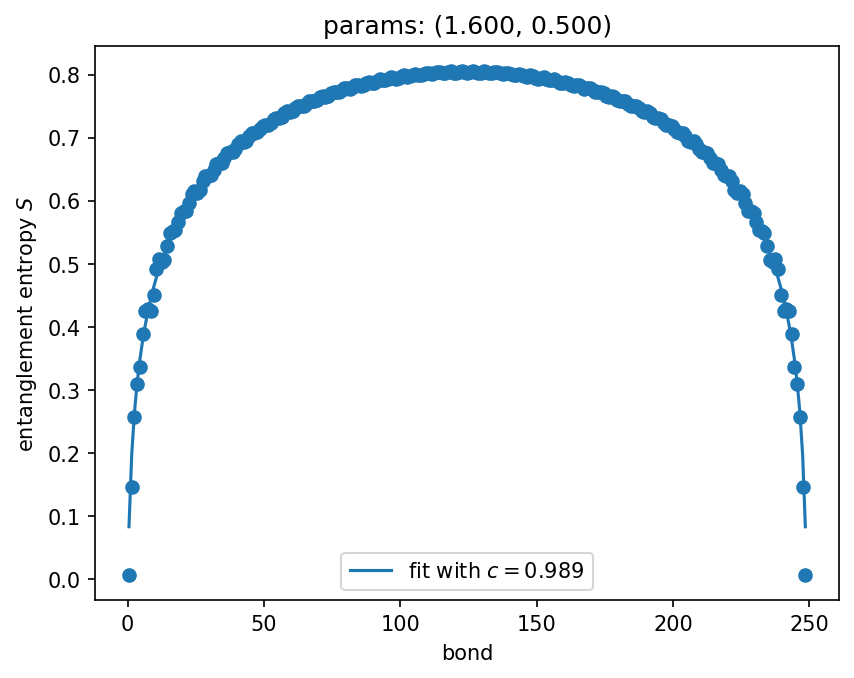

extraced central charge 0.98711 with residuum 2.09e-04


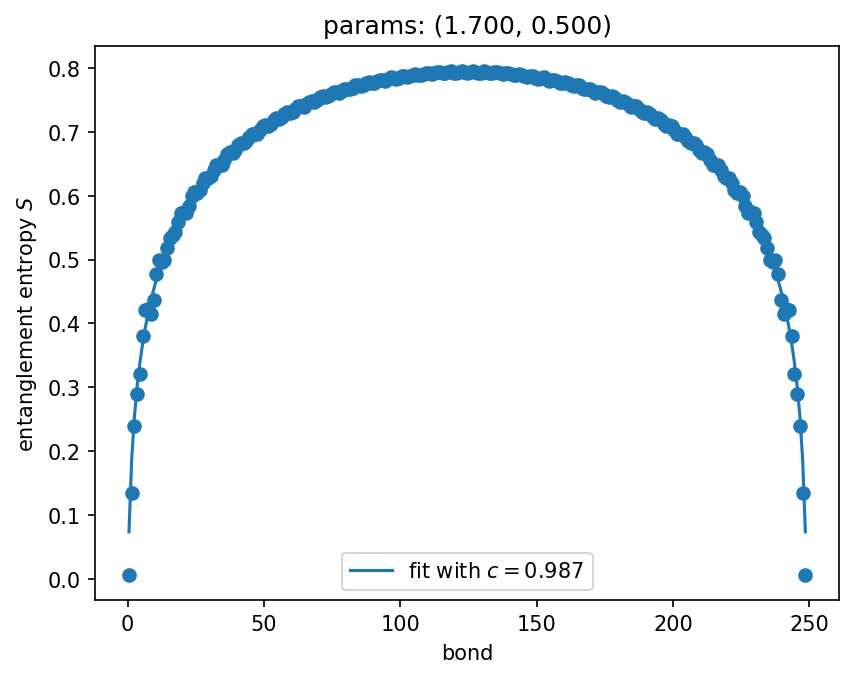

extraced central charge 0.98760 with residuum 2.01e-04


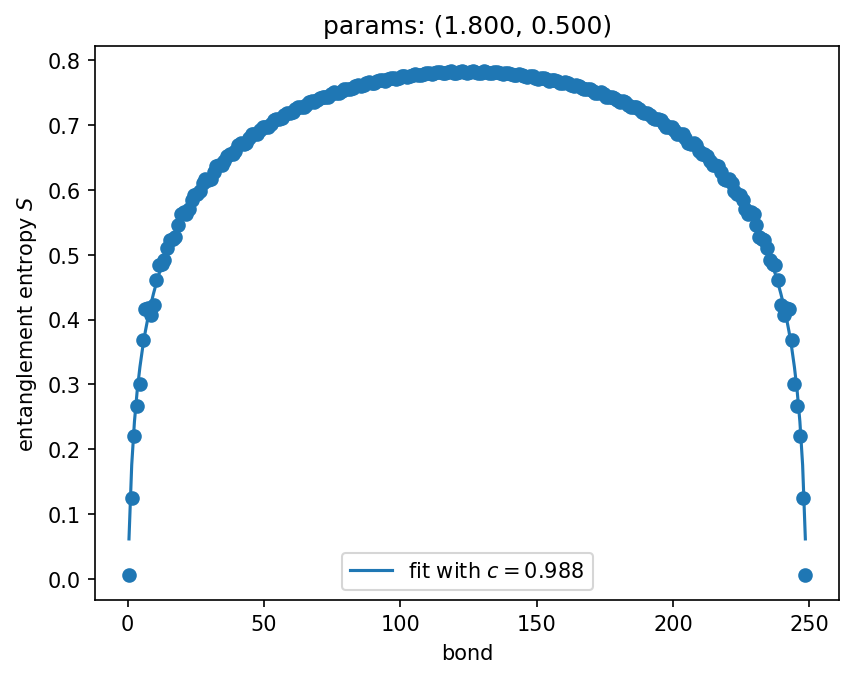

extraced central charge 0.98611 with residuum 1.91e-04


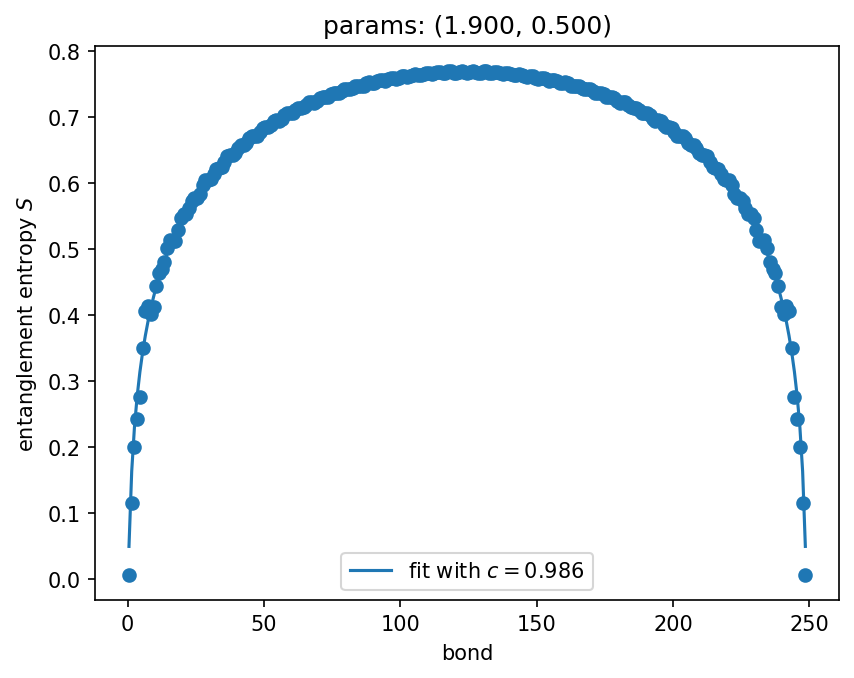

extraced central charge 0.99898 with residuum 2.76e-04


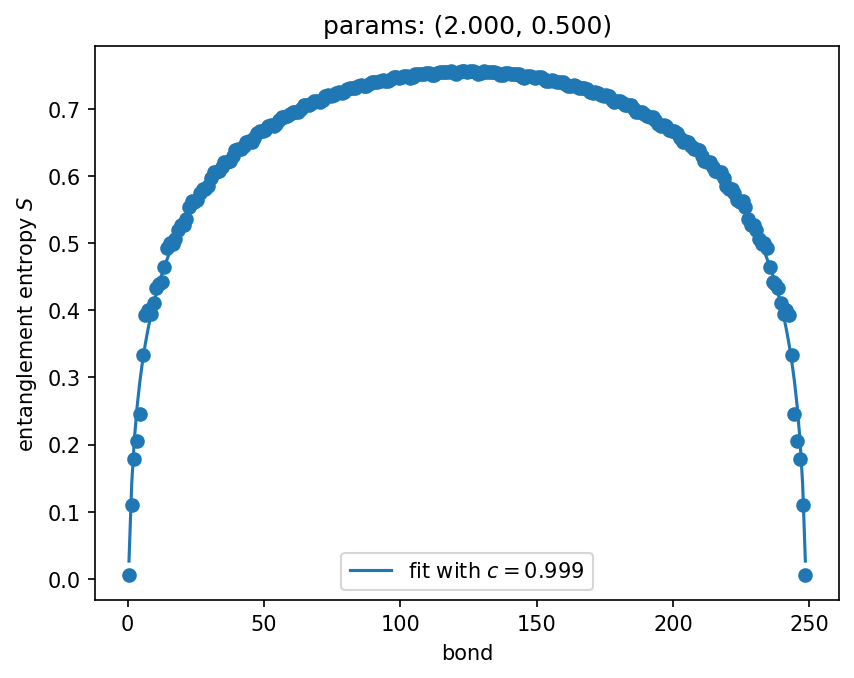

In [52]:
def linfun(x, c, consta):
    return (c/6) * x + consta

def conformal_distance(L, pos):
    return np.log((2*L/(np.pi) * np.sin((np.pi*pos)/L)))

c = []
ks = []

for i in sorted(os.listdir(filename)):
    h, k = os.path.splitext(i)[0].split("_")[2:4]
    loc = os.path.join(filename, i)
    with open(loc, 'rb') as f:
        data = pickle.load(f)
        psi = data['psi']
    S = psi.entanglement_entropy()

    bonds = np.arange(0.5, psi.L-1)
    cut = 1

    conformal_bonds   = conformal_distance(psi.L, bonds[psi.L//2])
    conformal_entropy = S[psi.L//2:]
    # popt, pcov = curve_fit(linfun, conformal_bonds[cut:-cut], conformal_entropy[cut:-cut])
    # plt.plot(conformal_bonds[cut:-cut], conformal_entropy[cut:-cut], 'o', label="S")
    # plt.plot(conformal_bonds[cut:-cut], linfun(conformal_bonds[cut:-cut], *popt), label=f"{popt[0]}")

    plt.scatter(bonds, S)

    # preform fit to extract the central charge
    central_charge, const, res = tenpy.tools.fit.central_charge_from_S_profile(psi)
    fit = tenpy.tools.fit.entropy_profile_from_CFT(bonds+0.5, psi.L, central_charge, const)
    print(f"extraced central charge {central_charge:.5f} with residuum {res:.2e}")
    plt.title(f"params: ({h}, {k})")
    plt.plot(bonds, fit, label=f"fit with $c={central_charge:.3f}$")
    plt.xlabel("bond")
    plt.ylabel("entanglement entropy $S$")
    plt.legend()
    plt.show()

    c.append(central_charge)
    ks.append(float(h))



In [ ]:
plt.figure(figsize=(10,5))
plt.plot(ks, c)
plt.xticks(ks[::2])
plt.yticks([-1, -0.5, 0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5])
plt.show()